In [2]:
import gensn
import gensn.distributions as G
import torch
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import seaborn as sns
from task_transfer.routines import mc_marginal_log_likelihood
from scipy.special import i0
from task_transfer.utils.math_utils import cos2_von_mises
from task_transfer.sampling_models import OrientationDiscriminationModel
from task_transfer.ml_lib.flow import get_flow_prior_model
seed = 1123
torch.manual_seed(seed)
rng = default_rng(seed)

In [3]:
from task_transfer.utils.insilico_stimuli import generate_gabors

In [4]:
def lstsq_solution(Y, X):
    design_matrix = torch.cat([X, torch.ones_like(X[:, :1])], dim=1)
    solution = torch.inverse(design_matrix.T @ design_matrix) @ design_matrix.T @ Y
    A = solution[:-1]
    b = solution[-1]
    return A, b

In [5]:
n_g = 10
n_x = 49
c1_prob = 0.5
# c1_loc = np.pi/4
c1_loc = 0
c1_std = None
# c2_loc = 3*np.pi/4
c2_loc = np.pi/2
c2_std = None
g_pref_orientations = torch.linspace(0, 3*np.pi/4, steps=n_g)
# g_pref_orientations = torch.tensor([0, np.pi/4, np.pi/2, 3*np.pi/4])
g_tuning_specificity = 1.0
x_feedback_factor = 1.
x_tuning_specificity = 3.0
x_pref_orientations = torch.linspace(g_pref_orientations[0], g_pref_orientations[-1], steps=n_x)
obs_noise = 0.1
n_samples = 10_000

model = OrientationDiscriminationModel(
    c1_prob=c1_prob,
    c1_loc=c1_loc,
    c1_std=c1_std,
    c2_loc=c2_loc,
    c2_std=c2_std,
    g_pref_orientations=g_pref_orientations,
    g_tuning_specificity=g_tuning_specificity,
    x_feedback_factor=x_feedback_factor,
    x_tuning_specificity=x_tuning_specificity,
    x_pref_orientations=x_pref_orientations,
    obs_noise=obs_noise,
)

samples_dict = model.sample_prior(n_samples=10_000)

In [6]:
all_orientations = torch.linspace(-np.pi/4, np.pi, steps=1000)
tA_c1_orientation_density = (
    2 * np.pi / n_g * cos2_von_mises(all_orientations, model.c1_loc, 1.0)
)
tA_c2_orientation_density = (
    2 * np.pi / n_g * cos2_von_mises(all_orientations, model.c2_loc, 1.0)
)

NameError: name 'sampling_dict' is not defined

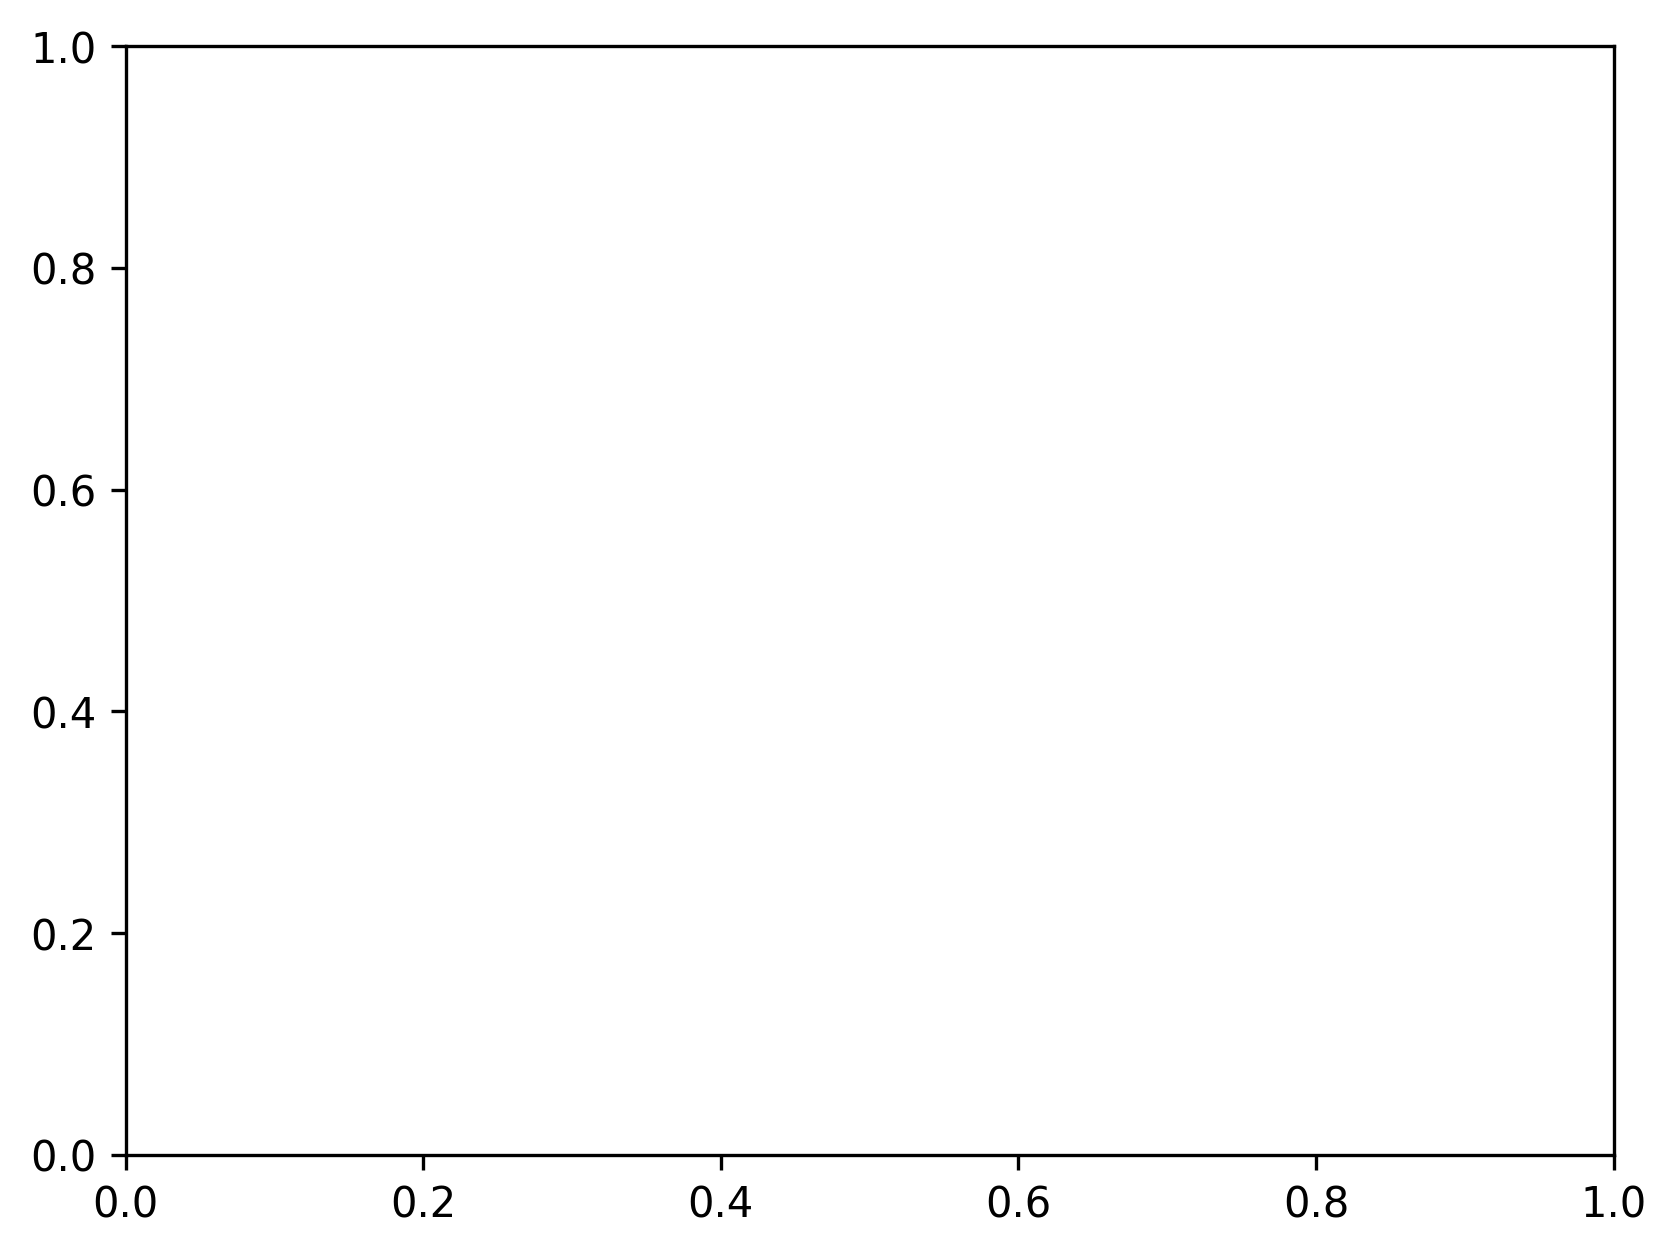

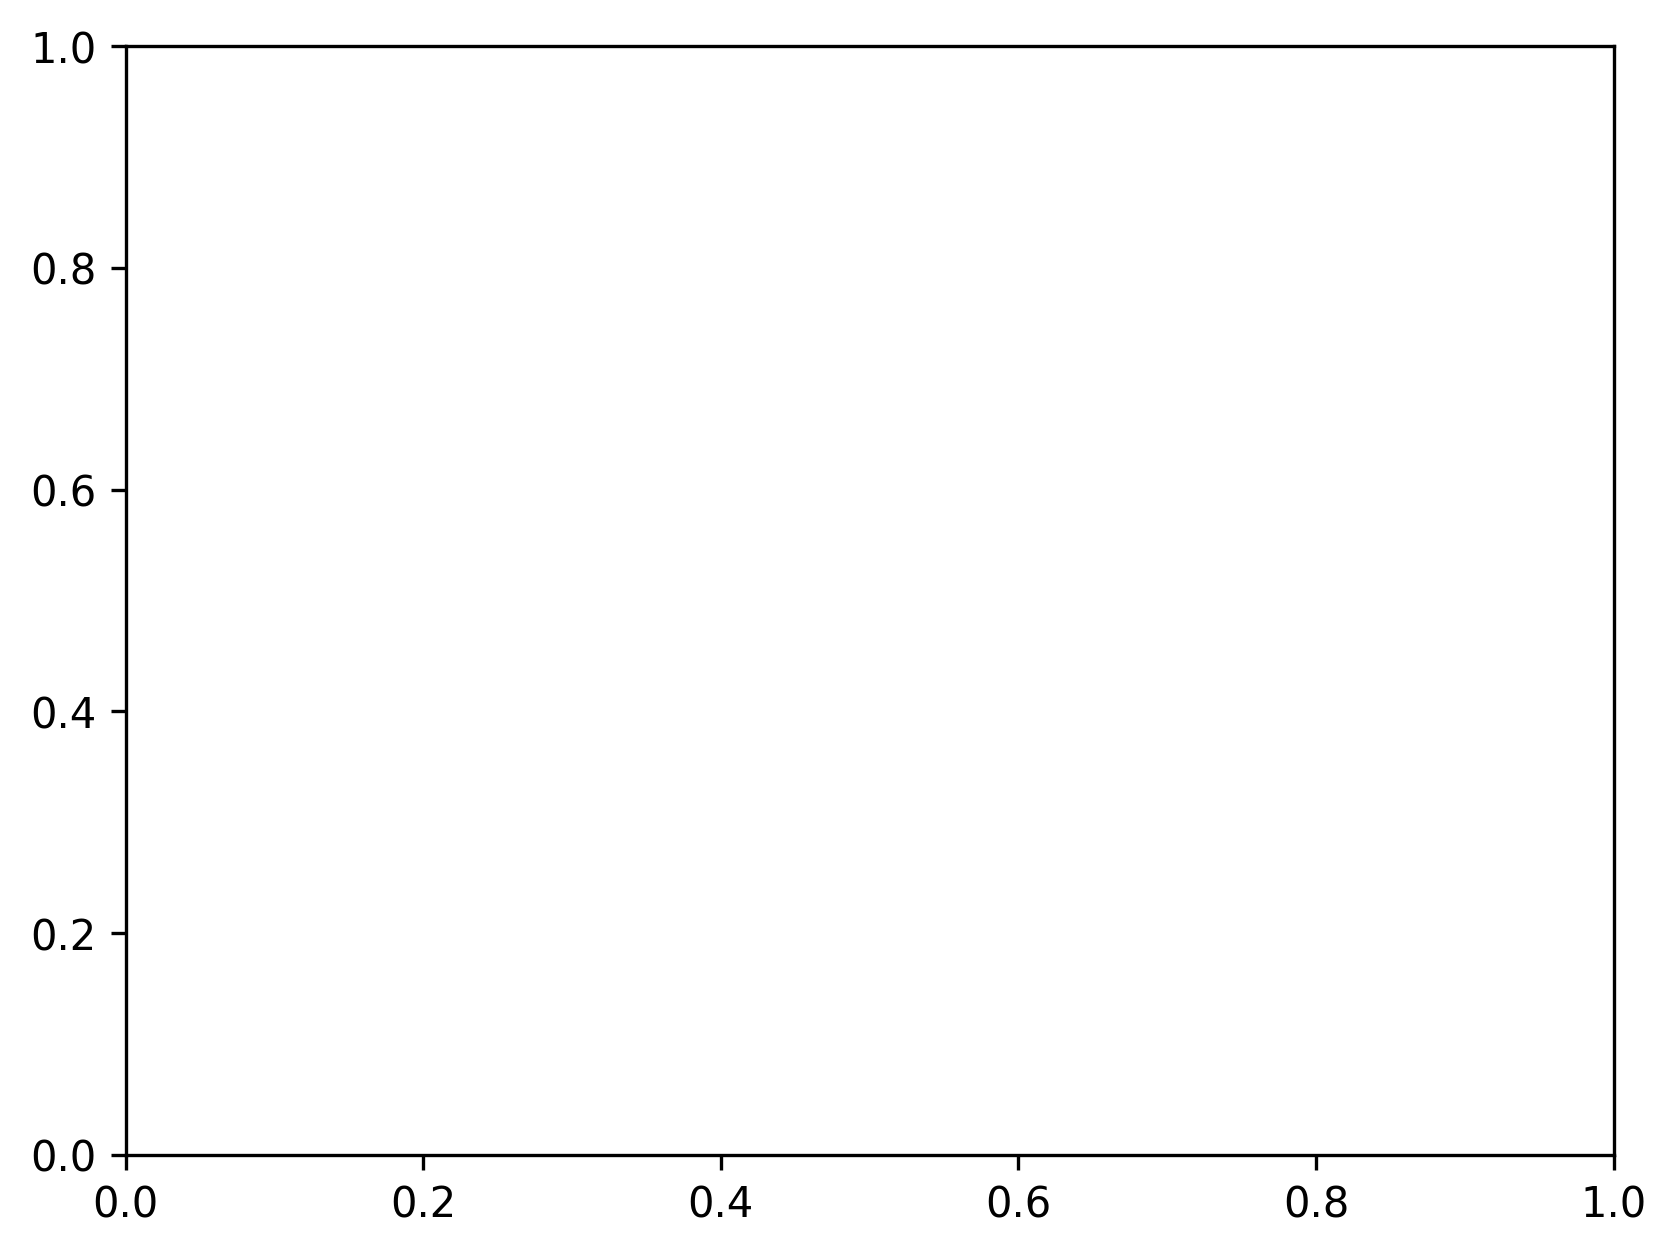

In [7]:
fig, ax = plt.subplots(dpi=300)
# ax.plot(
#     all_orientations, tA_c1_orientation_density, color="red", label="$P(\\theta|C=1)$"
# )
# ax.plot(
#     all_orientations, tA_c2_orientation_density, color="blue", label="$P(\\theta|C=2)$"
# )
fig, ax = plt.subplots(dpi=300)
ax.plot(all_orientations, sampling_dict['x_scale'], color="red", label="$P(\\theta|C=1)$")
# ax.plot(all_orientations, tA_c2_orientation_density, color="blue", label="$P(\\theta|C=2)$")
# ax.plot(
#     all_orientations,
#     (tA_c1_orientation_density + tA_c2_orientation_density) / 2,
#     color="orange",
#     linestyle="dotted",
# )
# ax.bar(x=g_preferred.flatten(), height=g_samples.mean(dim=0))
xticks = np.array([-np.pi/4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax.set_xticks(xticks)
ax.set_xticklabels(f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi)
ax.set_xlabel("Orientation $\\theta$ ($^\circ$)")
ax.set_yticks([0, 0.125, 0.25])
ax.set_ylabel("Probability $P(\\theta|C)$")
ax.legend(loc="upper right")
# ax.plot(
#     all_orientations,
#     (tA_c1_orientation_density + tA_c2_orientation_density) / 2,
#     color="orange",
#     linestyle="dotted",
# )
# ax.bar(x=g_preferred.flatten(), height=g_samples.mean(dim=0))
xticks = np.array([-np.pi / 4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax.set_xticks(xticks)
ax.set_xticklabels(f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi)
ax.set_xlabel("Orientation $\\theta$ ($^\circ$)")
ax.set_yticks([0, 0.125, 0.25])
ax.set_ylabel("Probability $P(\\theta|C)$")
ax.legend(loc="upper right")

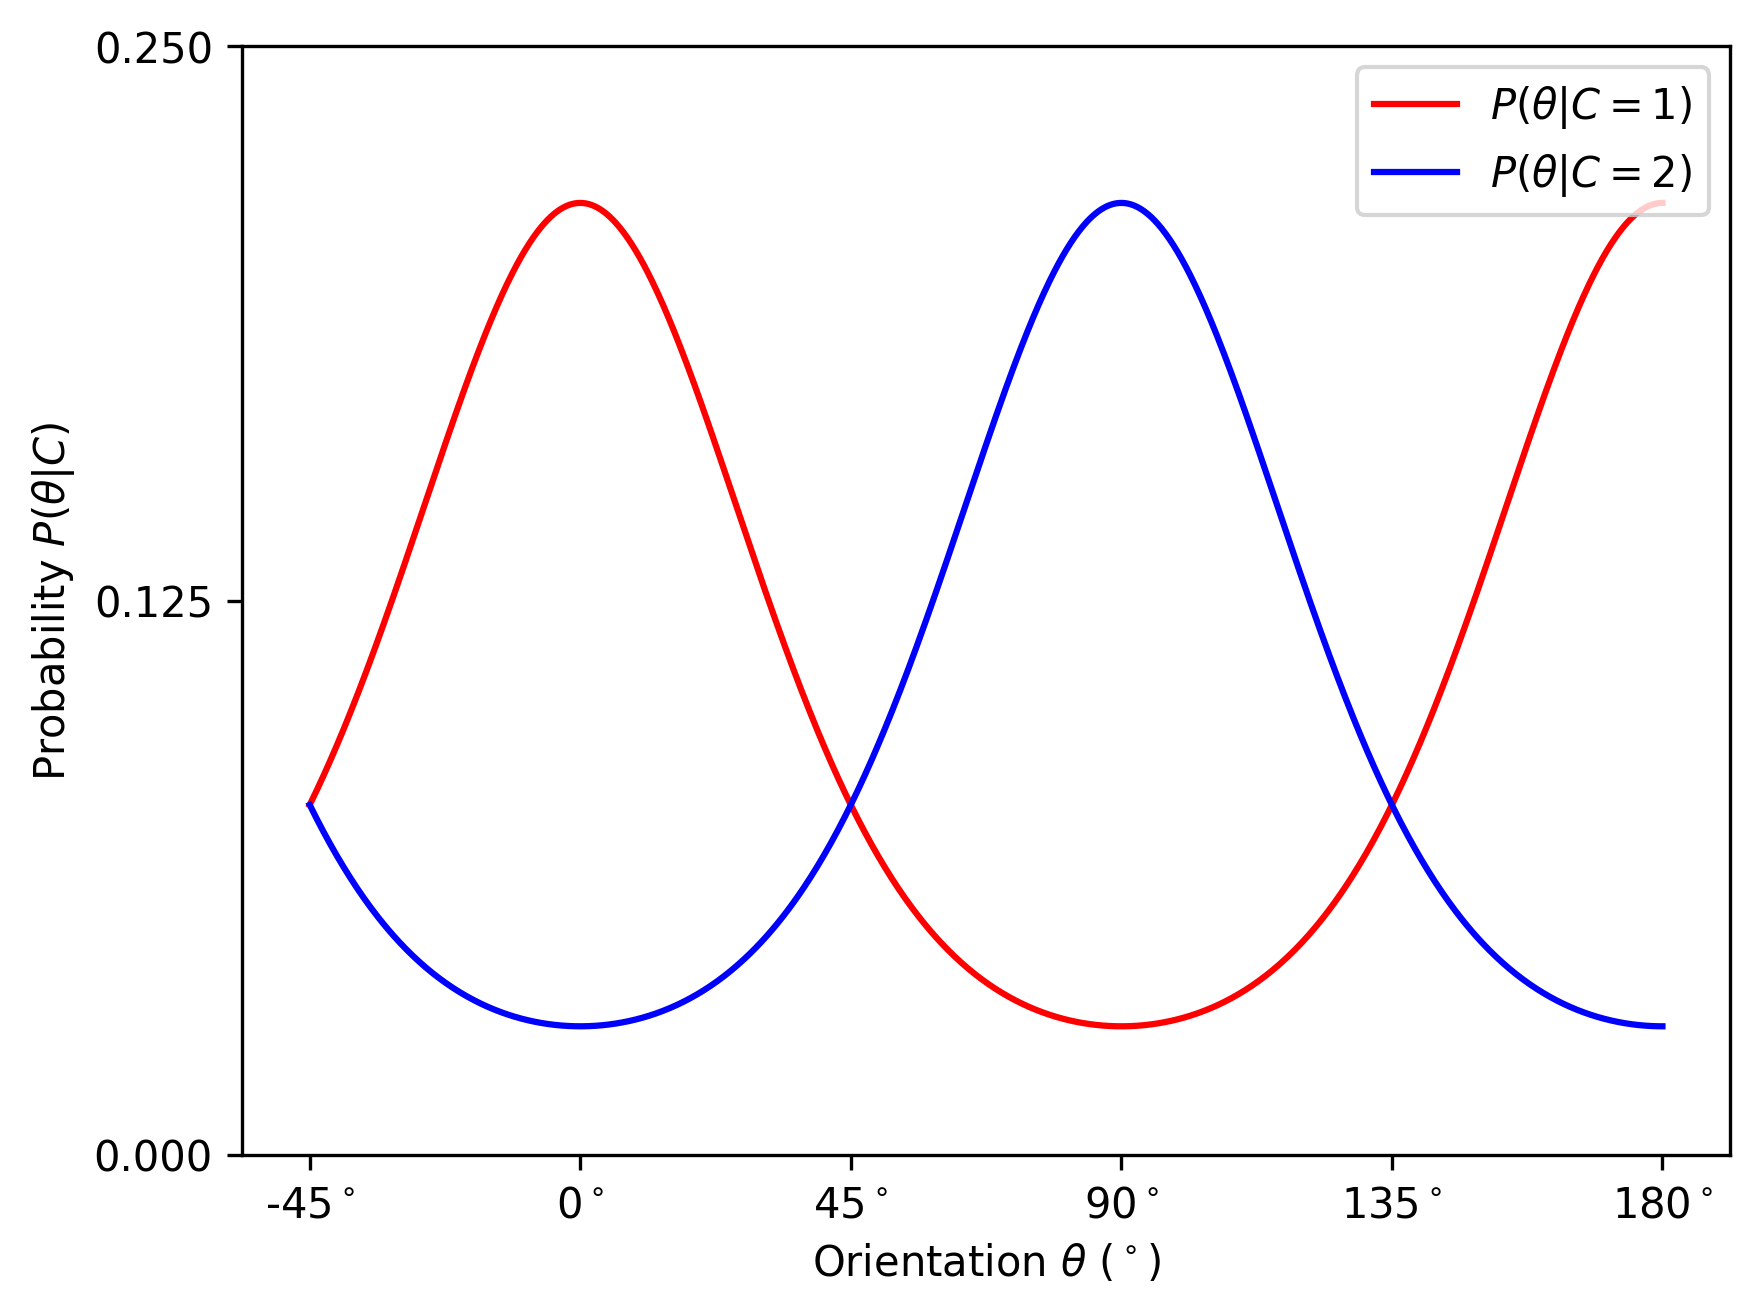

In [ ]:
fig, ax = plt.subplots(dpi=300)
ax.plot(all_orientations, tA_c1_orientation_density, color="red", label="$P(\\theta|C=1)$")
ax.plot(all_orientations, tA_c2_orientation_density, color="blue", label="$P(\\theta|C=2)$")
# ax.plot(
#     all_orientations,
#     (tA_c1_orientation_density + tA_c2_orientation_density) / 2,
#     color="orange",
#     linestyle="dotted",
# )
# ax.bar(x=g_preferred.flatten(), height=g_samples.mean(dim=0))
xticks = np.array([-np.pi/4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax.set_xticks(xticks)
ax.set_xticklabels(f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi)
ax.set_xlabel("Orientation $\\theta$ ($^\circ$)")
ax.set_yticks([0, 0.125, 0.25])
ax.set_ylabel("Probability $P(\\theta|C)$")
ax.legend(loc="upper right")

Text(0, 0.5, 'P(C)')

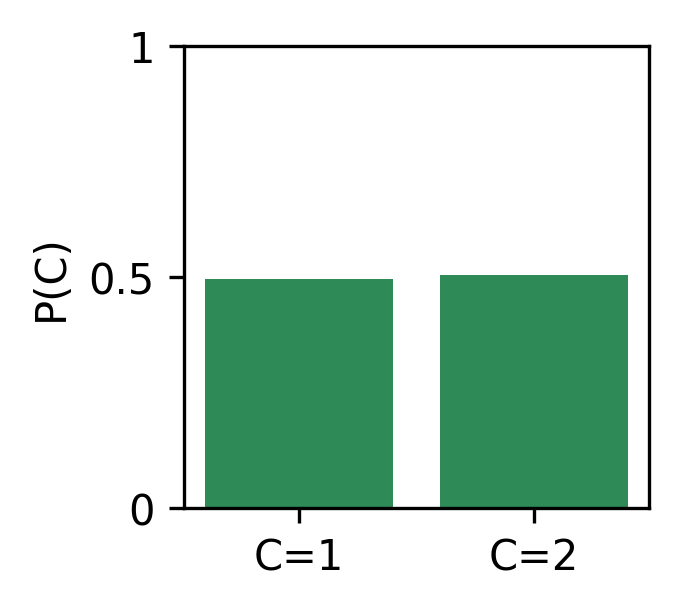

In [ ]:
fig, ax = plt.subplots(dpi=300, figsize=(2, 2))
x = [0, 1]
d_ones = samples_dict['c'].mean()
height = [1.0 - d_ones, d_ones]
ax.bar(x=x, height=height, color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(["C=1", "C=2"])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["0", "0.5", "1"])
ax.set_ylabel("P(C)")

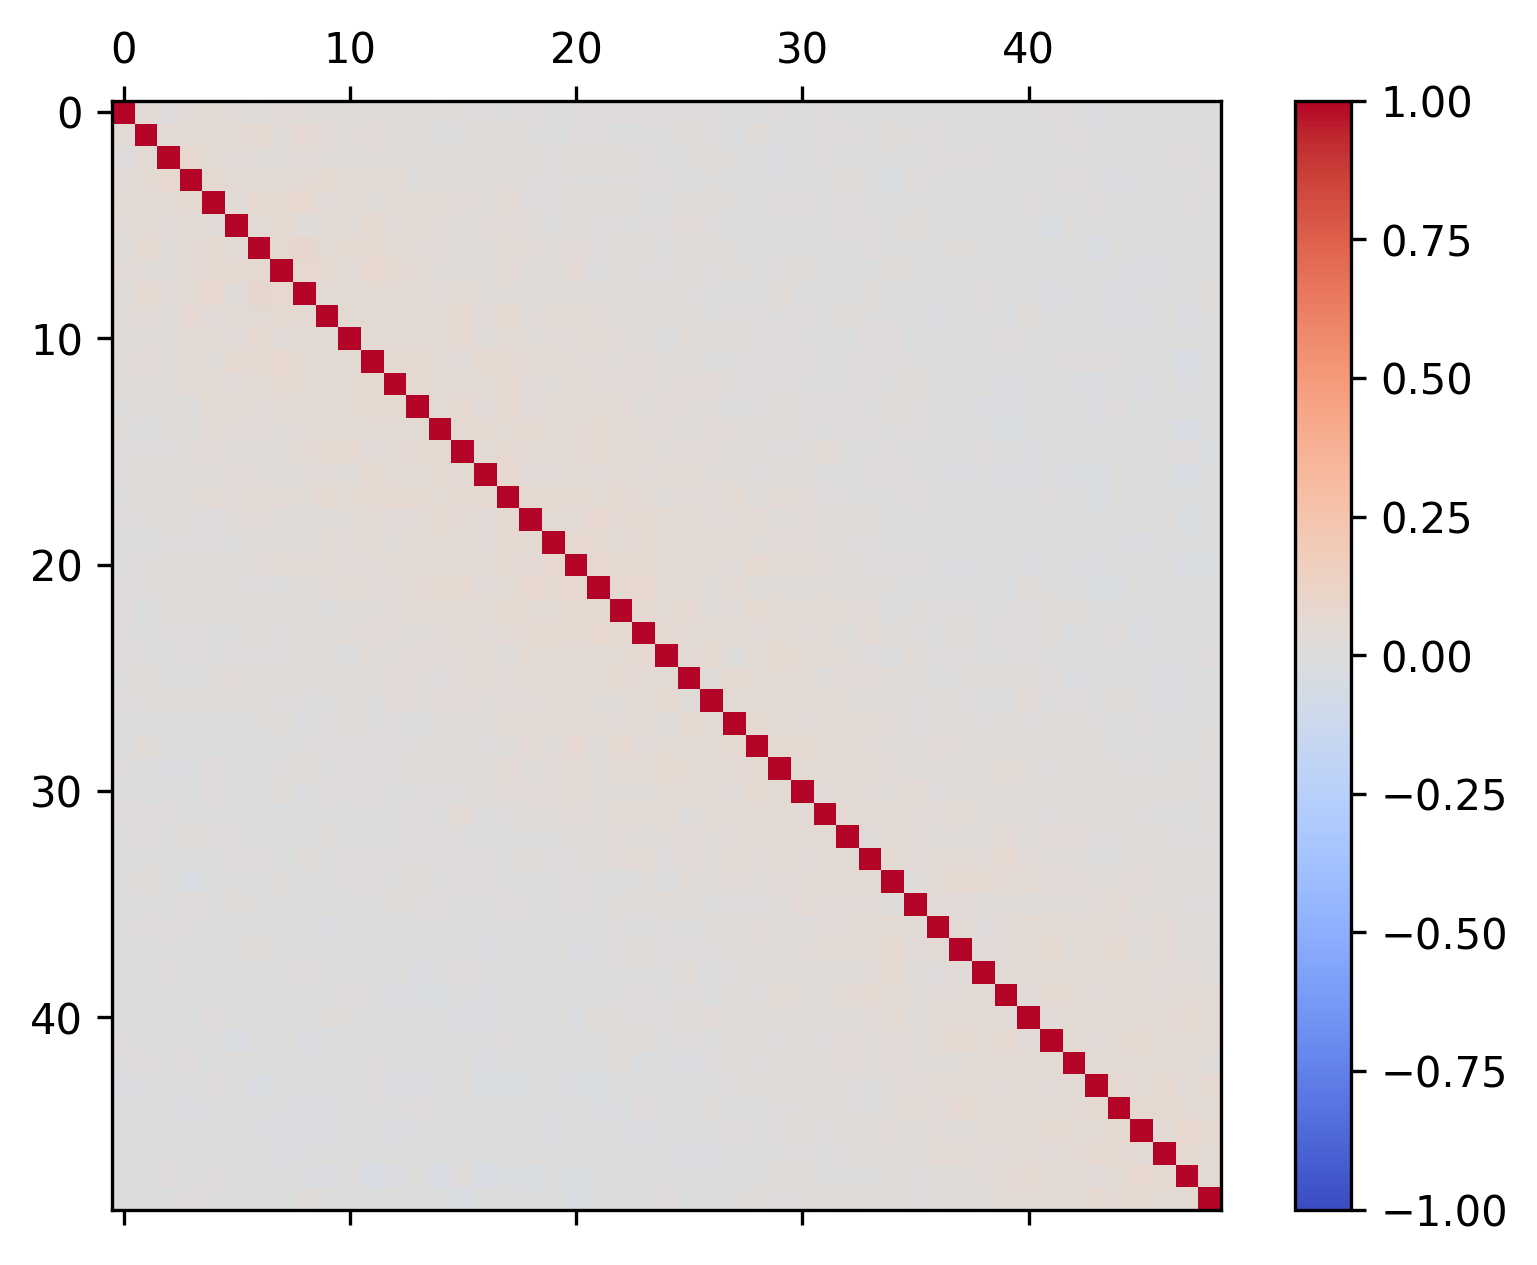

In [ ]:
corr = torch.corrcoef(samples_dict['x'].T)
# plot the correlation matrix
fig, ax = plt.subplots(dpi=300)
cax = ax.matshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax)

In [ ]:
corr.shape

torch.Size([49, 49])

<Axes: ylabel='Probability'>

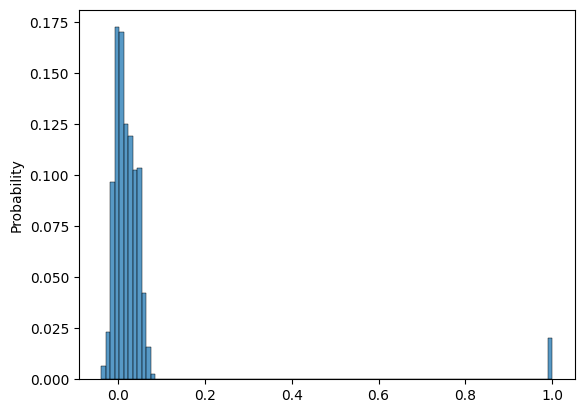

In [ ]:
sns.histplot(corr.flatten(), bins=100, stat='probability')

In [ ]:
samples_dict['x'].shape, samples_dict['i'].shape

(torch.Size([10000, 49]), torch.Size([10000, 144]))

In [ ]:
A, b = lstsq_solution(samples_dict['i'], samples_dict['x'])

In [8]:
samples_dict['g'].shape

torch.Size([10000, 10])

In [38]:
(samples_dict['g'] @ samples_dict['x_scale_factor']).mean(dim=0)

tensor([0.1202, 0.1300, 0.1395, 0.1485, 0.1569, 0.1648, 0.1720, 0.1786, 0.1846,
        0.1899, 0.1947, 0.1988, 0.2022, 0.2049, 0.2068, 0.2079, 0.2082, 0.2078,
        0.2067, 0.2050, 0.2027, 0.2000, 0.1969, 0.1937, 0.1903, 0.1869, 0.1836,
        0.1805, 0.1778, 0.1755, 0.1737, 0.1726, 0.1720, 0.1721, 0.1728, 0.1740,
        0.1756, 0.1776, 0.1796, 0.1815, 0.1830, 0.1838, 0.1836, 0.1822, 0.1792,
        0.1744, 0.1679, 0.1596, 0.1498])

In [39]:
all_orientations = torch.linspace(-torch.pi/4, np.pi, steps=100)

[Text(-0.7853981633974483, 0, '-45'),
 Text(0.0, 0, '0'),
 Text(0.7853981633974483, 0, '45'),
 Text(1.5707963267948966, 0, '90'),
 Text(2.356194490192345, 0, '135'),
 Text(3.141592653589793, 0, '180')]

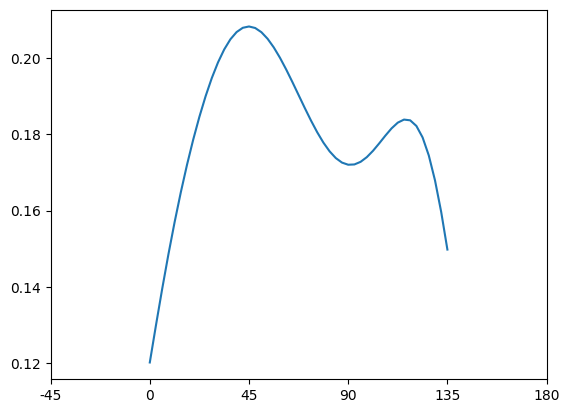

In [40]:
fig, ax = plt.subplots(dpi=100)
# ax.bar(x=g_preferred.flatten(), height=g_samples.mean(dim=0))
# ax.plot(x_pref_orientations, samples_dict["x_scale_factor"].sum(dim=0), marker="o", color="seagreen")
ax.plot(x_pref_orientations, (samples_dict["g"] @ samples_dict["x_scale_factor"]).mean(dim=0))
xticks = np.array([-np.pi/4, 0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax.set_xticks(xticks)
ax.set_xticklabels(int(xtick) for xtick in xticks * 180 / np.pi)

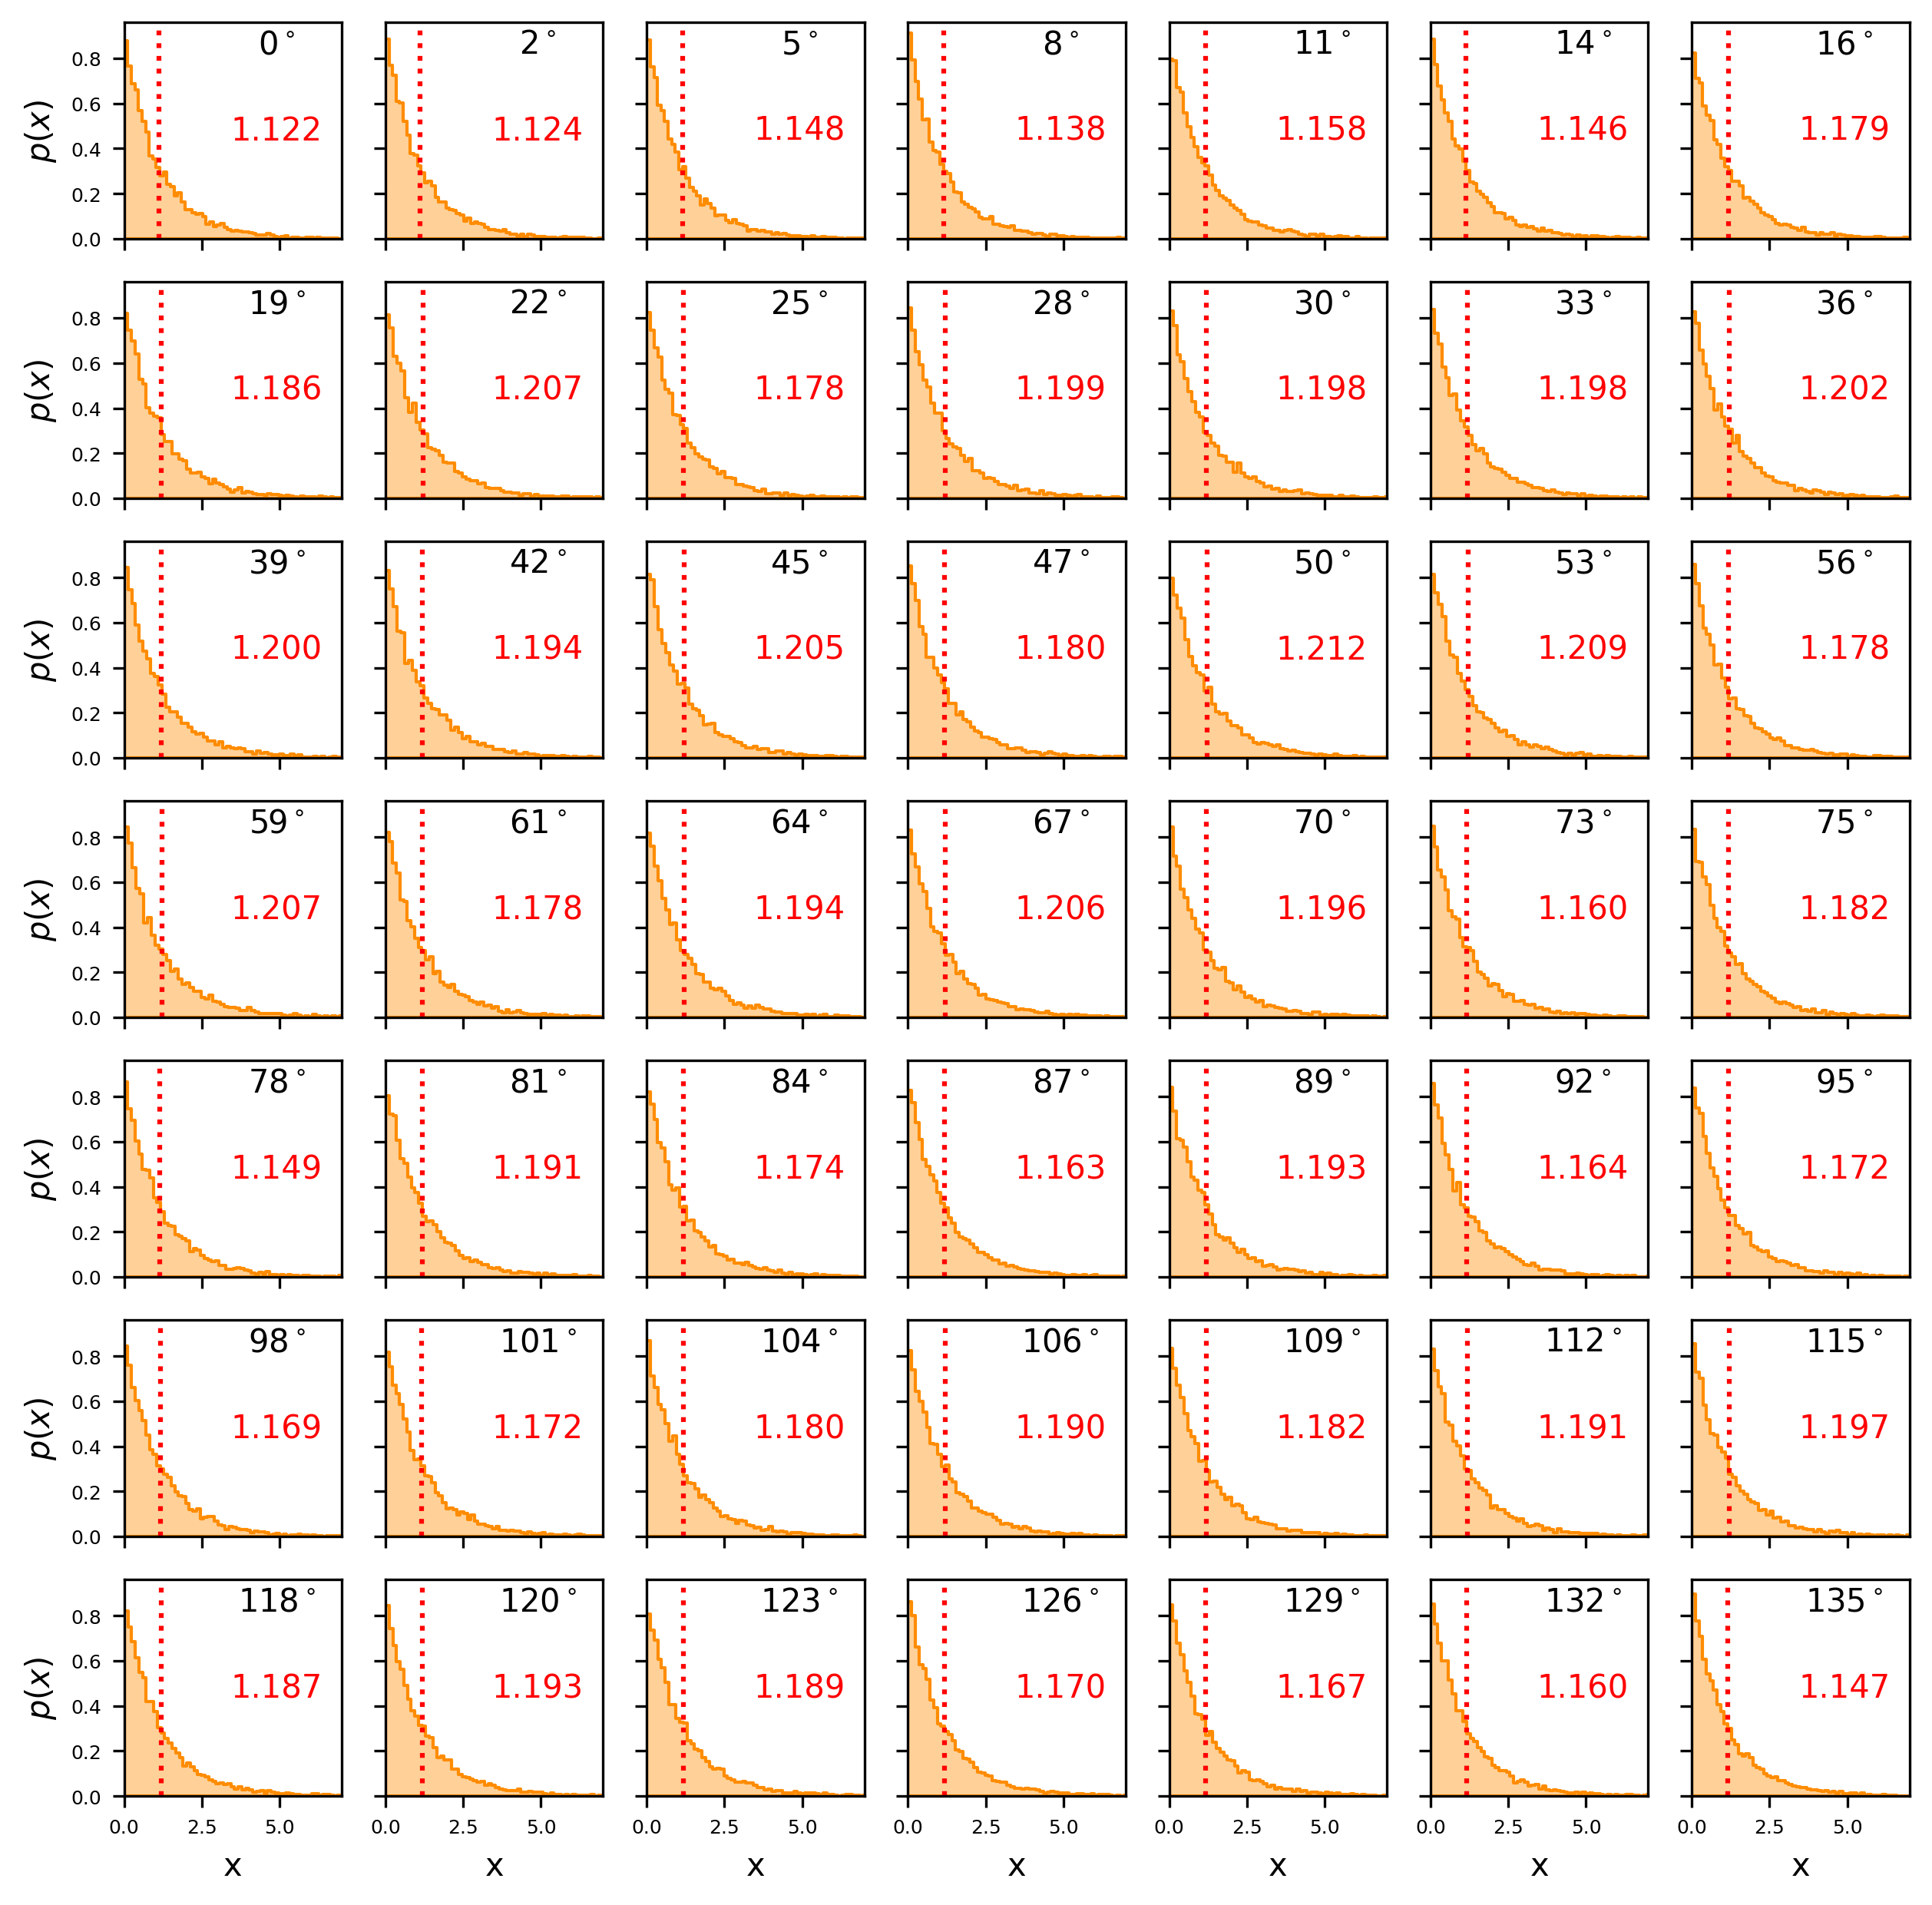

In [61]:
fig, axs = plt.subplots(7, 7, figsize=(10, 10), dpi=300, sharex=True, sharey=True)
for idx, ax in enumerate(axs.flatten()):
    sns.histplot(
        samples_dict['x'][:, idx],
        ax=ax,
        stat="density",
        element="step",
        # kde=True,
        color="darkorange",
        # label="No task",
        alpha=0.4,
    )
    ax.text(
        0.7,
        0.9,
        f"{int(np.rad2deg(x_pref_orientations[idx]))}$^\circ$",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
    )
    mean_samples = torch.mean(samples_dict['x'][:, idx])
    ax.axvline(mean_samples, color="red", linestyle="dotted")
    ax.text(
        0.7,
        0.5,
        f"{mean_samples:.3f}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
        color="red",
        label="Mean",
    )
    # mean_scales = np.mean(latent_scale_samples[:, idx])
    # ax.axvline(mean_scales, color="blue", linestyle="dotted", alpha=0.5)
    # ax.text(
    #     0.5,
    #     0.5,
    #     f"{mean_scales:.3f}",
    #     horizontalalignment="center",
    #     verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=6,
    #     color="blue",
    # )
    ax.set_xlim([0, 7])
    # ax.set_ylim([0, 20])
    ax.tick_params(axis="both", which="both", labelsize=6)
    ax.set_ylabel("$p(x)$", fontsize=10)
    ax.set_xlabel("x", fontsize=10)
# handles, labels = axs[0][0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower right")

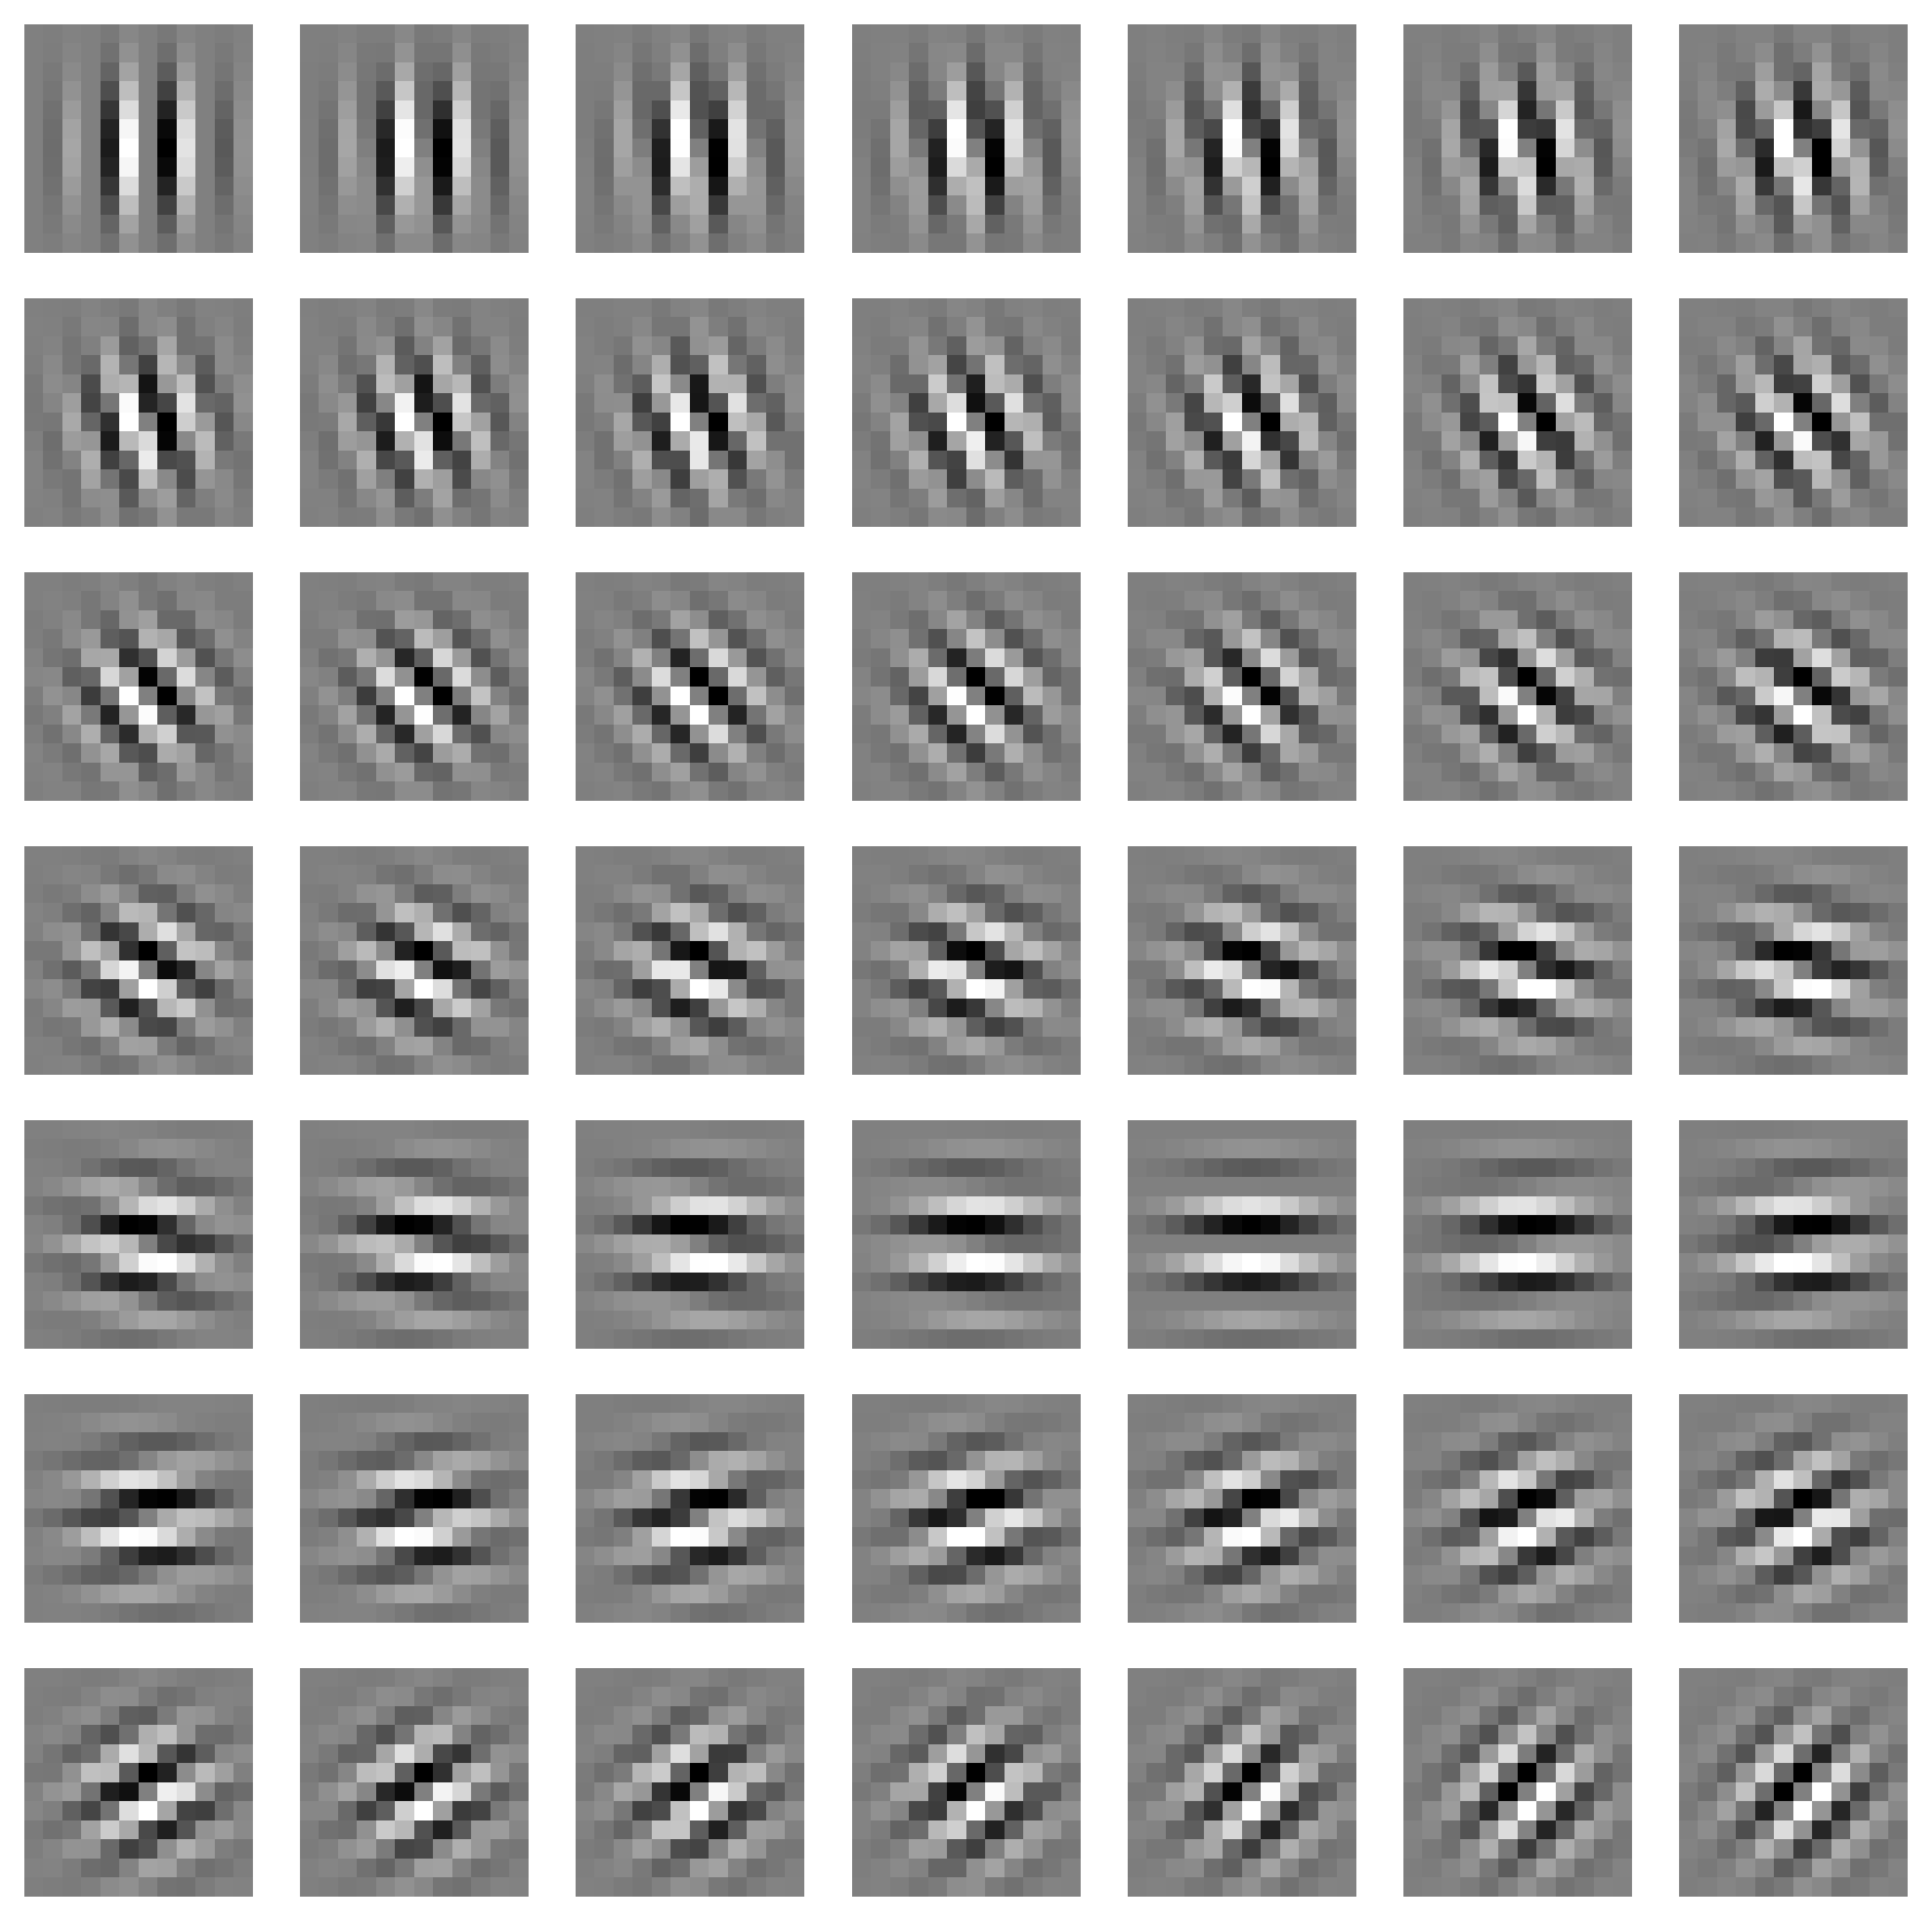

In [40]:
fig, axs = plt.subplots(7, 7, dpi=300, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(model.x_pfs[i].reshape(12, 12), cmap="gray")
    ax.axis("off")


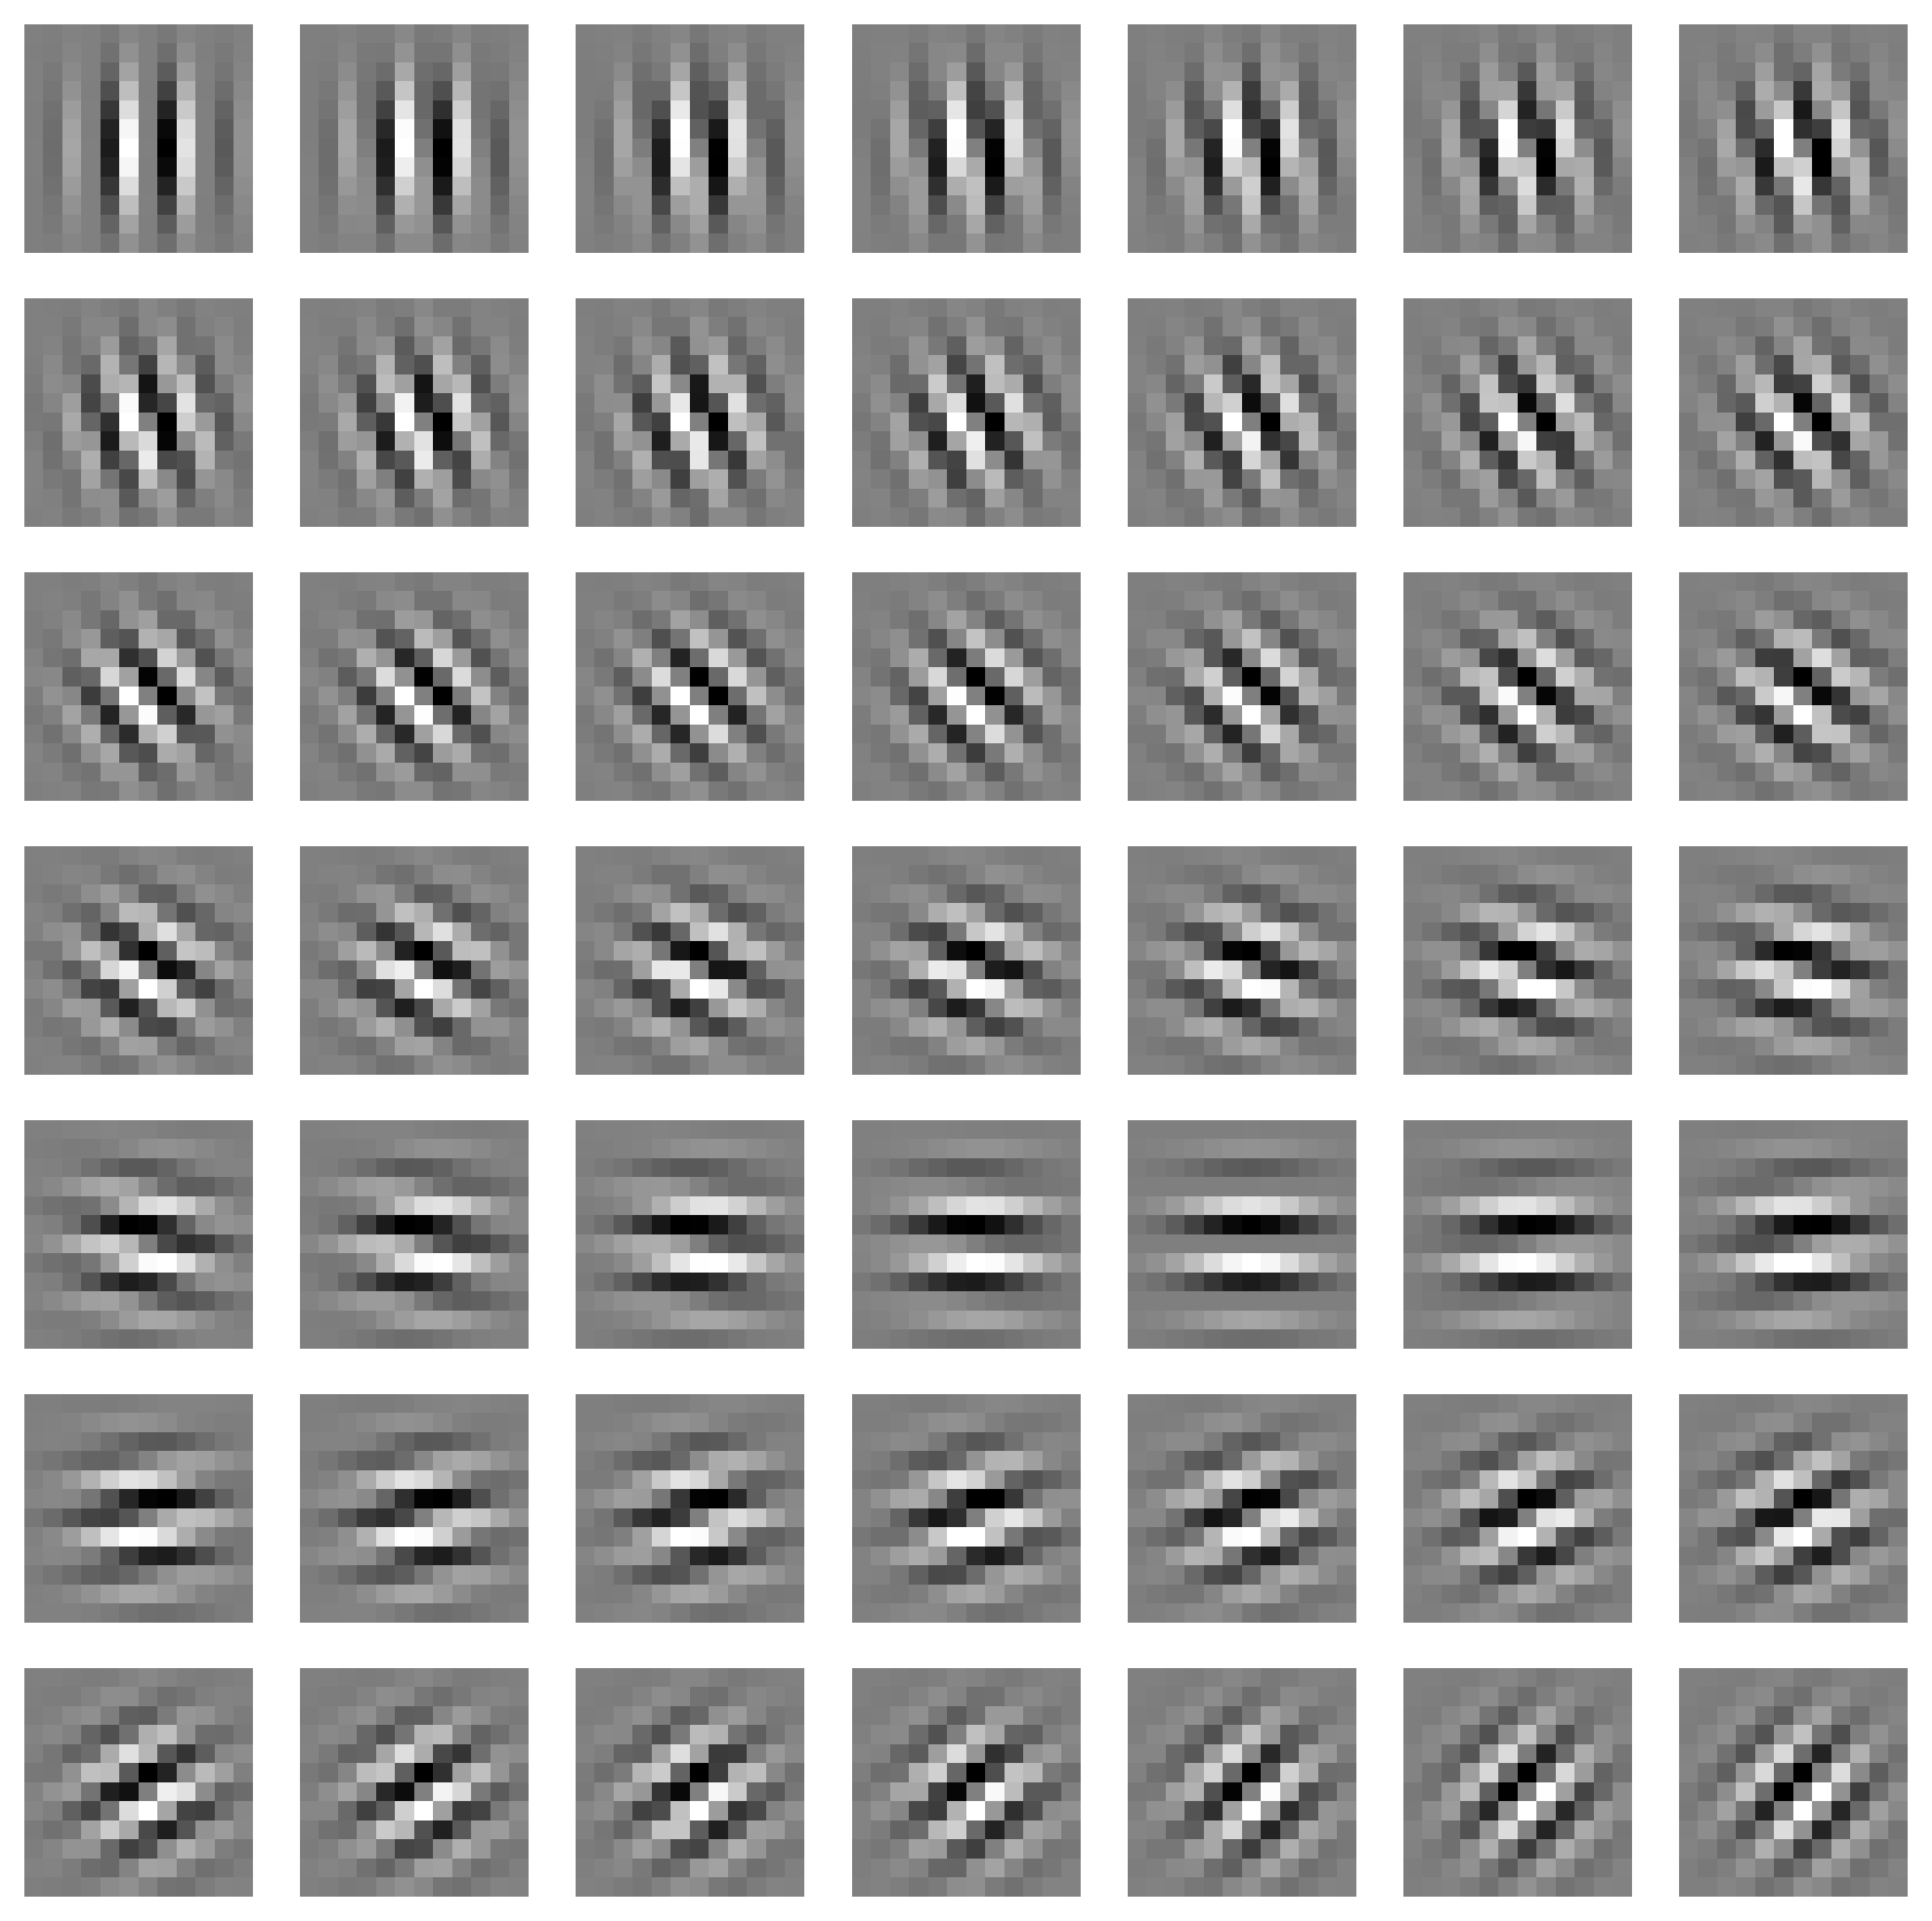

In [41]:
fig, axs = plt.subplots(7, 7, dpi=300, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(A[i].reshape(12, 12), cmap='gray')
    ax.axis('off')

In [12]:
model.x_pfs.shape

torch.Size([49, 12, 12])

In [13]:
(model.x_pfs.flatten() - A.flatten()).mean()

tensor(-3.0708e-06)

<Axes: ylabel='Probability'>

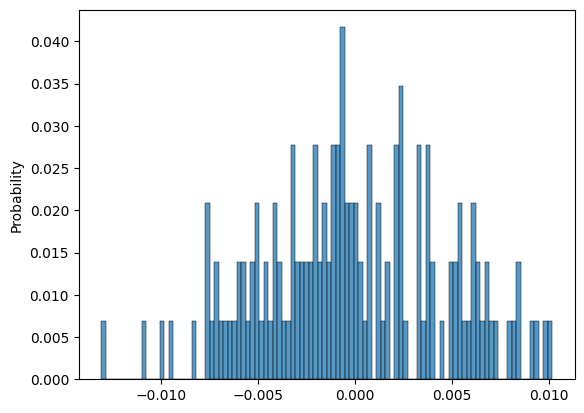

In [14]:
sns.histplot(b.flatten(), stat='probability', bins=100)

In [44]:
flow_model_config = dict(
            flow_depth=2,
            flow_initial_nonlinearity="inv_softplus",
            flow_nonlinearity="tanh",
            flow_base_distribution="normal",
        )
flow_prior_model = get_flow_prior_model(
    dims=n_x,
    **flow_model_config,
)

In [45]:
flow_prior_model

FlowDistribution(
  (base_distribution): IndependentNormal(
    (trainable_distribution): IndependentTrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.normal.Normal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
              0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
              0.]), scale=tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
              1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
              1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), event_dims=1
    )
  )
  (transform): SequentialTransform(
    (transforms): ModuleList(
      (0): InverseTransform(
        (transform): Softplus()
      )
      (1): IndependentAffine()
      (2): Tanh()
      (3): IndependentAffine()
      (4): Tanh()
      (5): IndependentAffine()
    )
  )
)

In [46]:
from torch.utils.data import DataLoader, TensorDataset

In [47]:
samples_dict['x']

tensor([[2.6808e-01, 2.4825e-01, 2.1349e+00,  ..., 7.7649e-01, 3.7541e-03,
         2.8699e+00],
        [2.1902e-02, 1.2011e+00, 4.9051e-01,  ..., 6.2939e+00, 7.0414e+00,
         9.9058e-01],
        [1.3108e+00, 6.6677e-01, 1.0455e+00,  ..., 2.9558e+00, 3.7201e-01,
         1.2675e+00],
        ...,
        [9.4134e-01, 1.3433e+00, 1.2249e-02,  ..., 4.1289e-02, 1.2725e-01,
         2.5805e-01],
        [1.3783e+00, 2.5611e-01, 5.7254e-02,  ..., 3.9401e-01, 1.4242e-01,
         3.7777e-01],
        [2.5573e+00, 1.6016e+00, 2.3087e-01,  ..., 2.7999e+00, 1.3591e-01,
         7.1220e-01]])

In [48]:
train_x = samples_dict['x'][:int(n_samples*0.8)]
test_x = samples_dict['x'][int(n_samples*0.8):]
# convert to tensor dataset
train_loader = DataLoader(TensorDataset(train_x), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(test_x), batch_size=128, shuffle=False)

In [49]:
# write a simple pytorch training loop
n_epochs = 200
batch_size = 128
optim = torch.optim.Adam(flow_prior_model.parameters(), lr=1e-3)
for epoch in range(n_epochs):
    for batch in train_loader:
        optim.zero_grad()
        log_prob = flow_prior_model.log_prob(batch[0])
        loss = -log_prob.mean()
        loss.backward()
        optim.step()
    print(f"Epoch {epoch+1}/{n_epochs}, loss: {loss.item()}")

Epoch 1/200, loss: 386.6918640136719
Epoch 2/200, loss: 350.1650390625
Epoch 3/200, loss: 329.2215270996094
Epoch 4/200, loss: 314.73028564453125
Epoch 5/200, loss: 298.56512451171875
Epoch 6/200, loss: 268.8104553222656
Epoch 7/200, loss: 249.7821044921875
Epoch 8/200, loss: 238.48655700683594
Epoch 9/200, loss: 213.82308959960938
Epoch 10/200, loss: 205.8108367919922
Epoch 11/200, loss: 190.8439483642578
Epoch 12/200, loss: 175.501220703125
Epoch 13/200, loss: 163.82012939453125
Epoch 14/200, loss: 150.85890197753906
Epoch 15/200, loss: 137.17230224609375
Epoch 16/200, loss: 126.13058471679688
Epoch 17/200, loss: 115.8770980834961
Epoch 18/200, loss: 105.25257873535156
Epoch 19/200, loss: 96.42185974121094
Epoch 20/200, loss: 92.0523452758789
Epoch 21/200, loss: 84.5947036743164
Epoch 22/200, loss: 75.93051147460938
Epoch 23/200, loss: 73.41545867919922
Epoch 24/200, loss: 70.37020111083984
Epoch 25/200, loss: 70.47084045410156
Epoch 26/200, loss: 66.30744171142578
Epoch 27/200, loss

In [50]:
test_losses = []
with torch.no_grad():
    flow_prior_model.eval()
    for batch in test_loader:
        optim.zero_grad()
        log_prob = flow_prior_model.log_prob(batch[0])
        loss = -log_prob.mean()
        test_losses.append(loss.item())
        # print(f"Batch test loss: {loss.item()}")
print(np.mean(test_losses))

57.074140787124634


In [51]:
x = torch.linspace(1e-3, 10, 1000).repeat(n_x, 1).T

In [52]:
x.shape

torch.Size([1000, 49])

In [53]:
with torch.no_grad():
    flow_prior_model.eval()
    density = flow_prior_model.factorized_log_prob(x).exp()

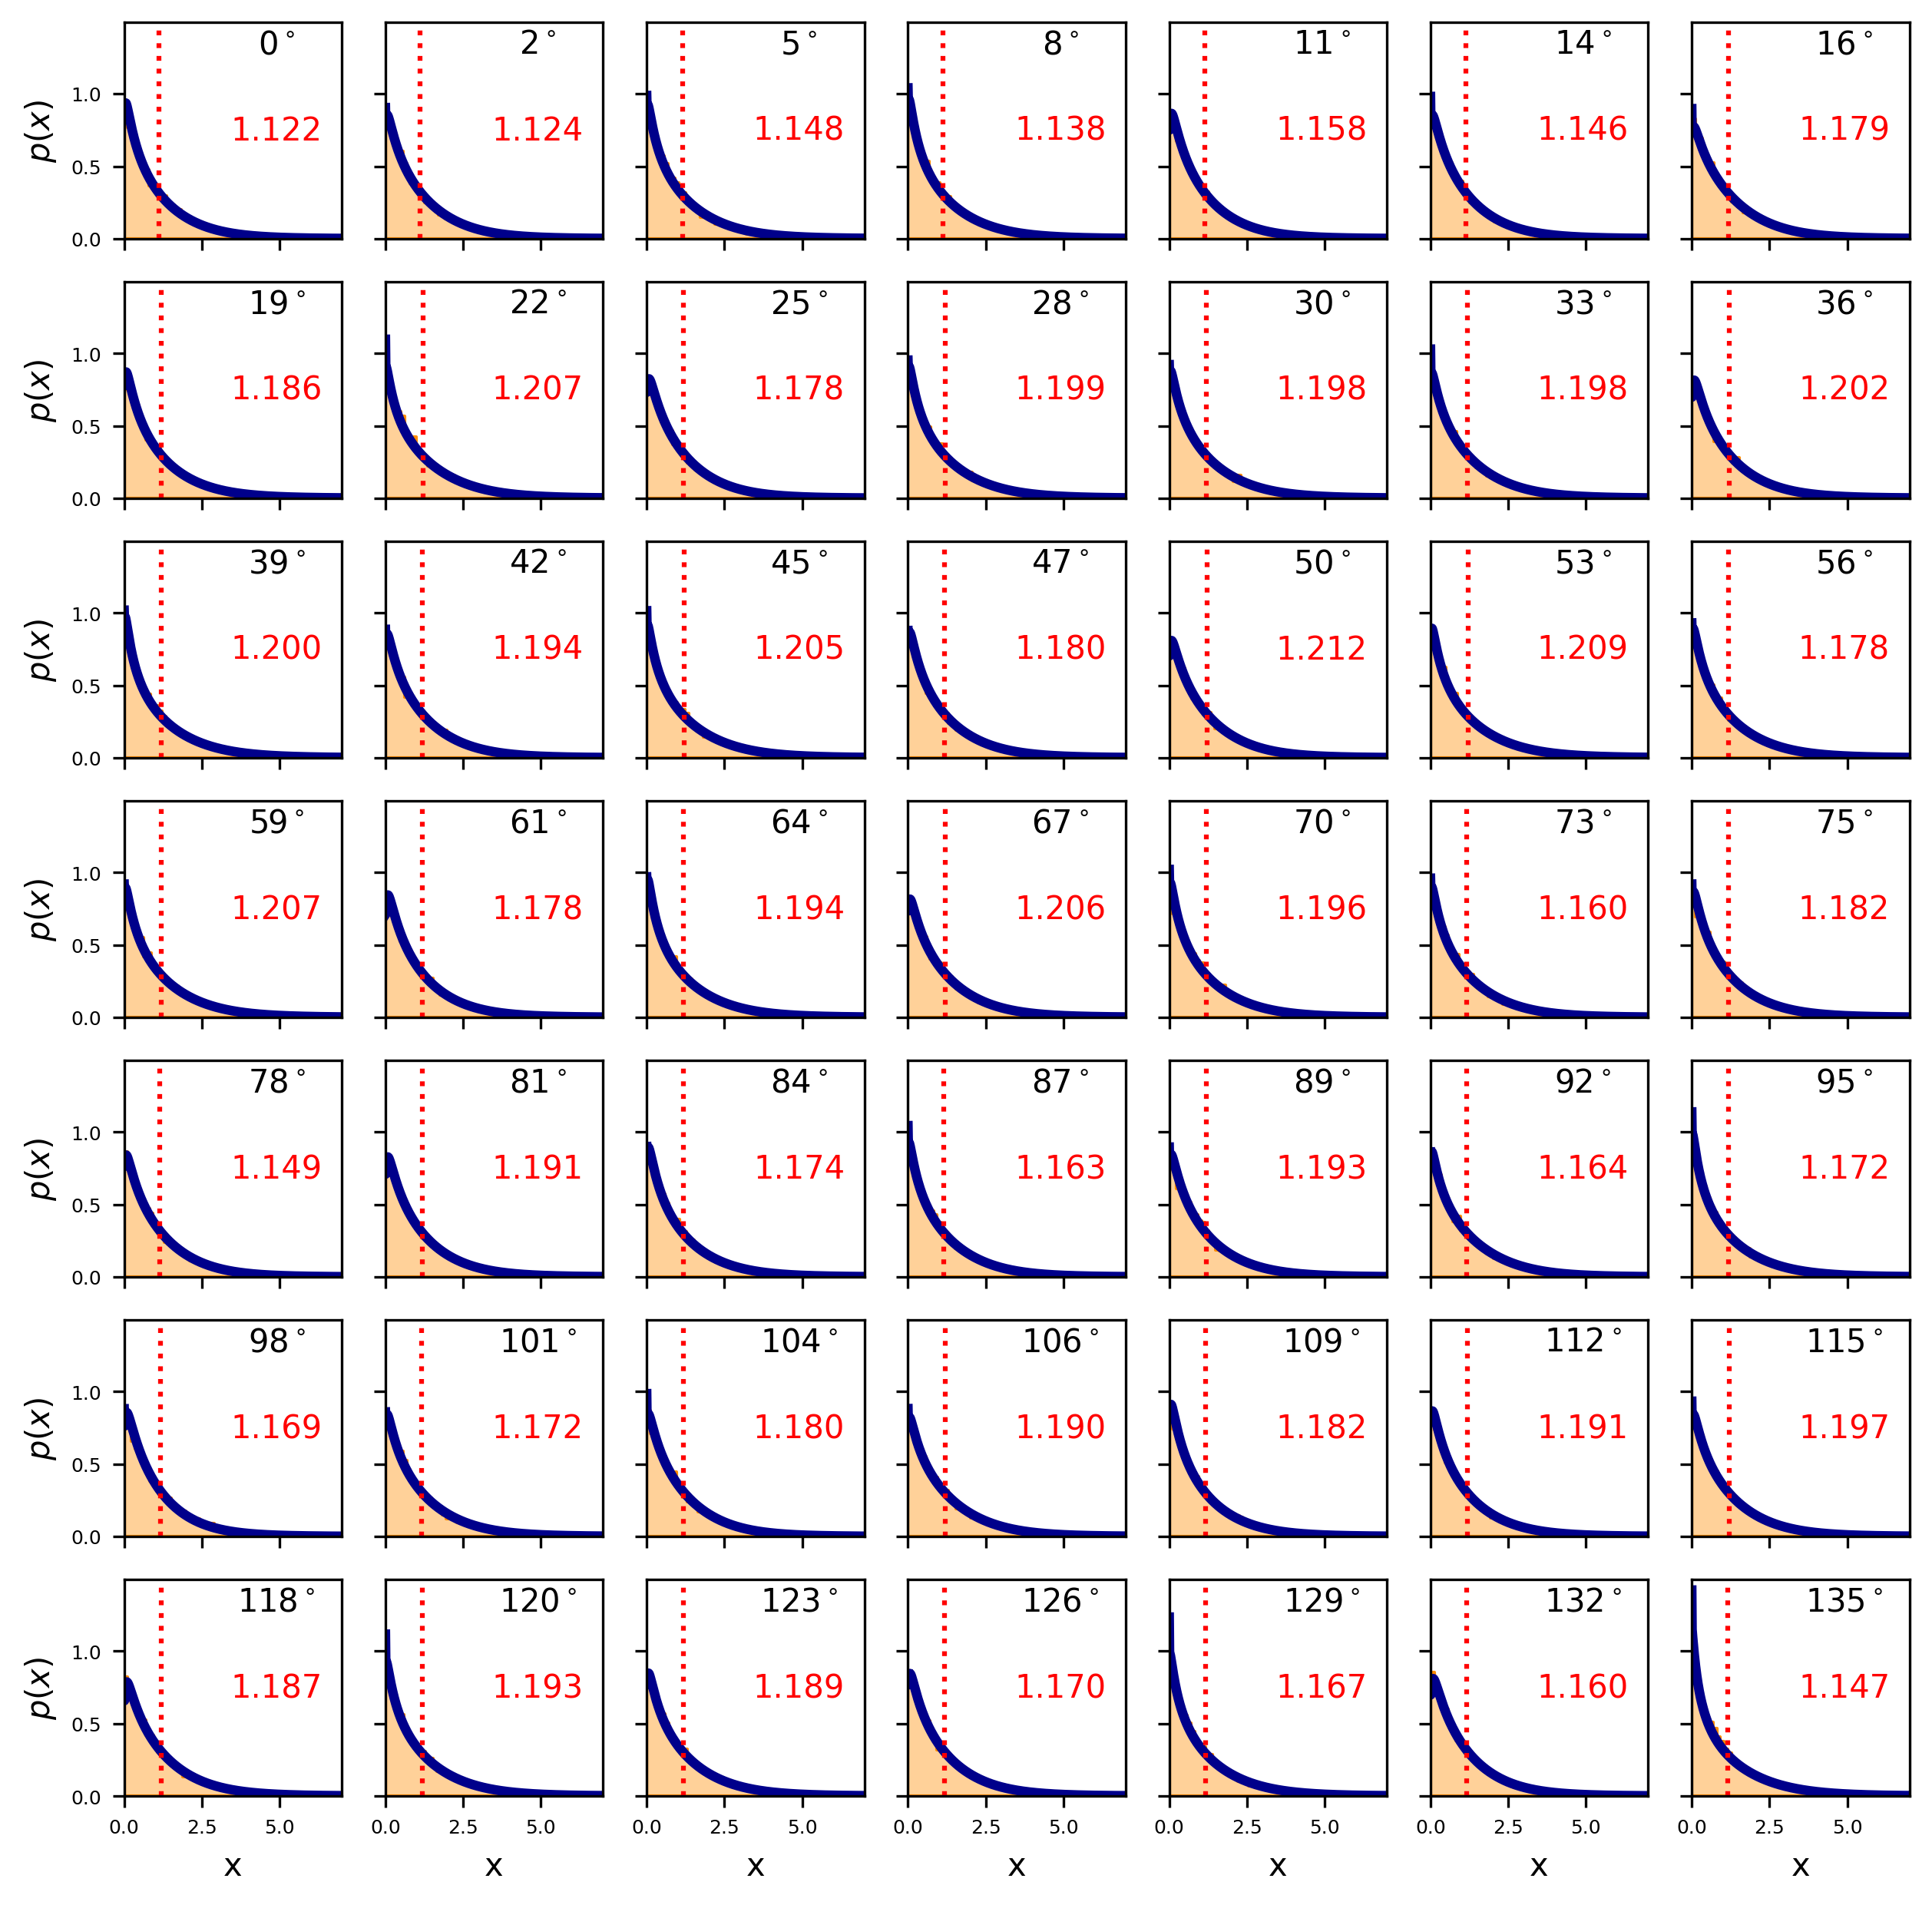

In [60]:
fig, axs = plt.subplots(7, 7, figsize=(10, 10), dpi=300, sharex=True, sharey=True)
for idx, ax in enumerate(axs.flatten()):
    ax.plot(x[:, idx], density[:, idx], linewidth=3, color="darkblue")
    sns.histplot(
        samples_dict["x"][:, idx],
        ax=ax,
        stat="density",
        element="step",
        # kde=True,
        color="darkorange",
        # label="No task",
        alpha=0.4,
    )
    ax.text(
        0.7,
        0.9,
        f"{int(np.rad2deg(x_pref_orientations[idx]))}$^\circ$",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
    )
    mean_samples = torch.mean(samples_dict["x"][:, idx])
    ax.axvline(mean_samples, color="red", linestyle="dotted")
    ax.text(
        0.7,
        0.5,
        f"{mean_samples:.3f}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
        color="red",
        label="Mean",
    )
    # mean_scales = np.mean(latent_scale_samples[:, idx])
    # ax.axvline(mean_scales, color="blue", linestyle="dotted", alpha=0.5)
    # ax.text(
    #     0.5,
    #     0.5,
    #     f"{mean_scales:.3f}",
    #     horizontalalignment="center",
    #     verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=6,
    #     color="blue",
    # )
    ax.set_xlim([0, 10])
    # ax.set_ylim([0, 20])
    ax.tick_params(axis="both", which="both", labelsize=6)
    ax.set_ylabel("$p(x)$", fontsize=10)
    ax.set_xlabel("x", fontsize=10)
    # handles, labels = axs[0][0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc="lower right")
    # sns.histplot(samples_dict['x'][:, ii], stat='density', color='orange', ax=ax)
    ax.set_xlim(0, 7)
    # ax.axis("off")

In [ ]:
log_prob = flow_prior_model.log_prob(x[:, None])
prob = torch.exp(log_prob)
plt.plot(x, prob)

In [17]:
def cos2_von_mises(x, loc, concentration, normalized=True):
    exponent = torch.exp(concentration * torch.cos(2 * (x - loc)))
    if normalized:
        return exponent / (2 * torch.pi * i0(concentration))
    else:
        return exponent

In [6]:
n_samples = 10_000

In [7]:
d1_prob = 0.5
d2_prob = 1 - d1_prob

d_dist = D.Bernoulli(probs=torch.tensor([d1_prob]))
d_samples = d_dist.sample((n_samples,))

Text(0, 0.5, 'P(D)')

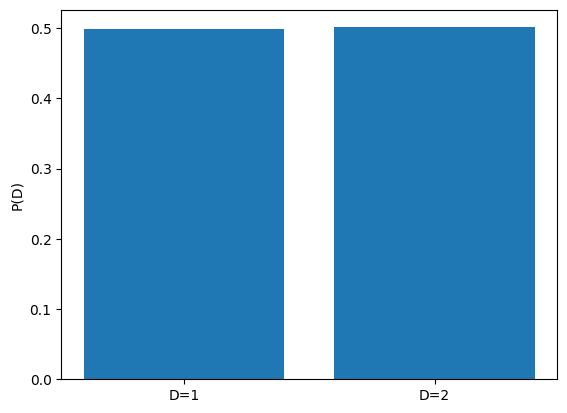

In [8]:
fig, ax = plt.subplots(dpi=100)
x = [0, 1]
d_ones = d_samples.mean()
height = [1. - d_ones, d_ones]
ax.bar(x=x, height=height)
ax.set_xticks(x)
ax.set_xticklabels(["D=1", "D=2"])
ax.set_ylabel("P(D)")

In [9]:
tA_c1_orientation = np.pi/4
tA_c2_orientation = 3 * np.pi/4
tA_orientations = torch.tensor([tA_c1_orientation, tA_c2_orientation])

In [10]:
all_orientations = torch.linspace(0, torch.pi, steps=10000).unsqueeze(-1)
tA_orientations.shape, all_orientations.shape

(torch.Size([2]), torch.Size([10000, 1]))

In [11]:
d_orientation_samples = tA_orientations[d_samples.long()]

In [12]:
g_preferred = torch.tensor([0., np.pi/4, np.pi/2, 3*np.pi/4]).reshape(-1, 1)
n_g = len(g_preferred)

In [13]:
d_orientation_samples.shape, g_preferred.shape

(torch.Size([10000, 1]), torch.Size([4, 1]))

In [14]:
diff_orientations = d_orientation_samples - g_preferred.T

In [15]:
g_vm_loc = 0.
g_vm_kappa = 1.
g_probs = 2 * np.pi / n_g * cos2_von_mises(diff_orientations, g_vm_loc, g_vm_kappa)

In [16]:
g_dist = D.Bernoulli(probs=g_probs)
g_samples = g_dist.sample()

In [17]:
all_orientations = torch.linspace(0, torch.pi, steps=10000)
tA_c1_orientation_density = 2 * np.pi / n_g * cos2_von_mises(all_orientations, tA_c1_orientation, g_vm_kappa)

In [18]:
tA_c2_orientation_density = (
    2 * np.pi / n_g * cos2_von_mises(all_orientations, tA_c2_orientation, g_vm_kappa)
)

In [19]:
g_samples.shape

torch.Size([10000, 4])

In [20]:
list(g_preferred.flatten())

[tensor(0.), tensor(0.7854), tensor(1.5708), tensor(2.3562)]

[Text(0.0, 0, '0'),
 Text(0.7853981633974483, 0, '45'),
 Text(1.5707963267948966, 0, '90'),
 Text(2.356194490192345, 0, '135'),
 Text(3.141592653589793, 0, '180')]

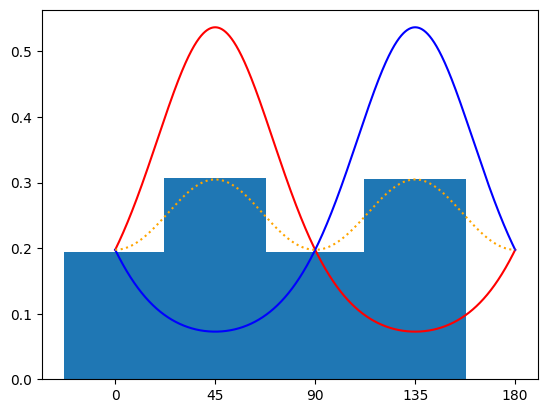

In [21]:
fig, ax = plt.subplots(dpi=100)
ax.plot(all_orientations, tA_c1_orientation_density, color="red", label="C=1")
ax.plot(all_orientations, tA_c2_orientation_density, color="blue", label="C=2")
ax.plot(all_orientations, (tA_c1_orientation_density + tA_c2_orientation_density)/2, color="orange", linestyle="dotted")
ax.bar(x=g_preferred.flatten(), height=g_samples.mean(dim=0))
xticks = np.array([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
ax.set_xticks(xticks)
ax.set_xticklabels(int(xtick) for xtick in xticks * 180 / np.pi)

Text(0.5, 0, 'g')

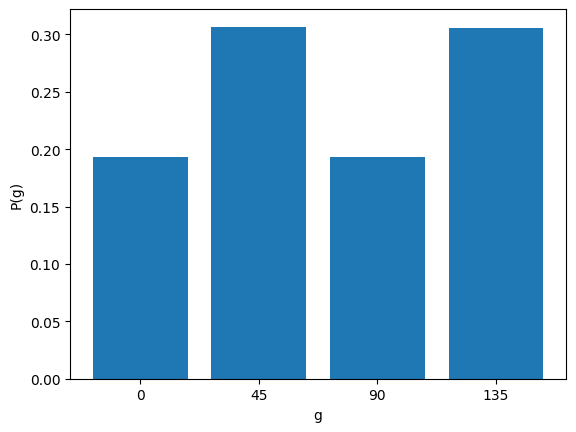

In [22]:
fig, ax = plt.subplots(dpi=100)
x = np.arange(n_g)
height = g_samples.mean(dim=0)
ax.bar(x=x, height=height)
ax.set_xticks(x)
ax.set_xticklabels(["0", "45", "90", "135"])
ax.set_ylabel("P(g)")
ax.set_xlabel("g")

In [23]:
x_preferred = torch.linspace(g_preferred[0].item(), g_preferred[-1].item(), steps=25).unsqueeze(-1).reshape(1, -1)

In [24]:
g_preferred.shape, x_preferred.shape

(torch.Size([4, 1]), torch.Size([1, 25]))

In [25]:
(g_preferred - x_preferred).shape

torch.Size([4, 25])

In [26]:
x_delta = 10
x_vm_kappa = 1.
x_vm_loc = 0.
x_scale_factor = cos2_von_mises(g_preferred - x_preferred, loc=x_vm_loc, concentration=x_vm_kappa)

In [27]:
g_samples.shape, x_scale_factor.shape

(torch.Size([10000, 4]), torch.Size([4, 25]))

In [28]:
x_scale = 1 + x_delta * g_samples @ x_scale_factor
x_scale.shape

torch.Size([10000, 25])

In [29]:
x_dist = D.Exponential(rate=1 / x_scale)

In [30]:
x_samples = x_dist.sample()

In [31]:
x_samples.shape

torch.Size([10000, 25])

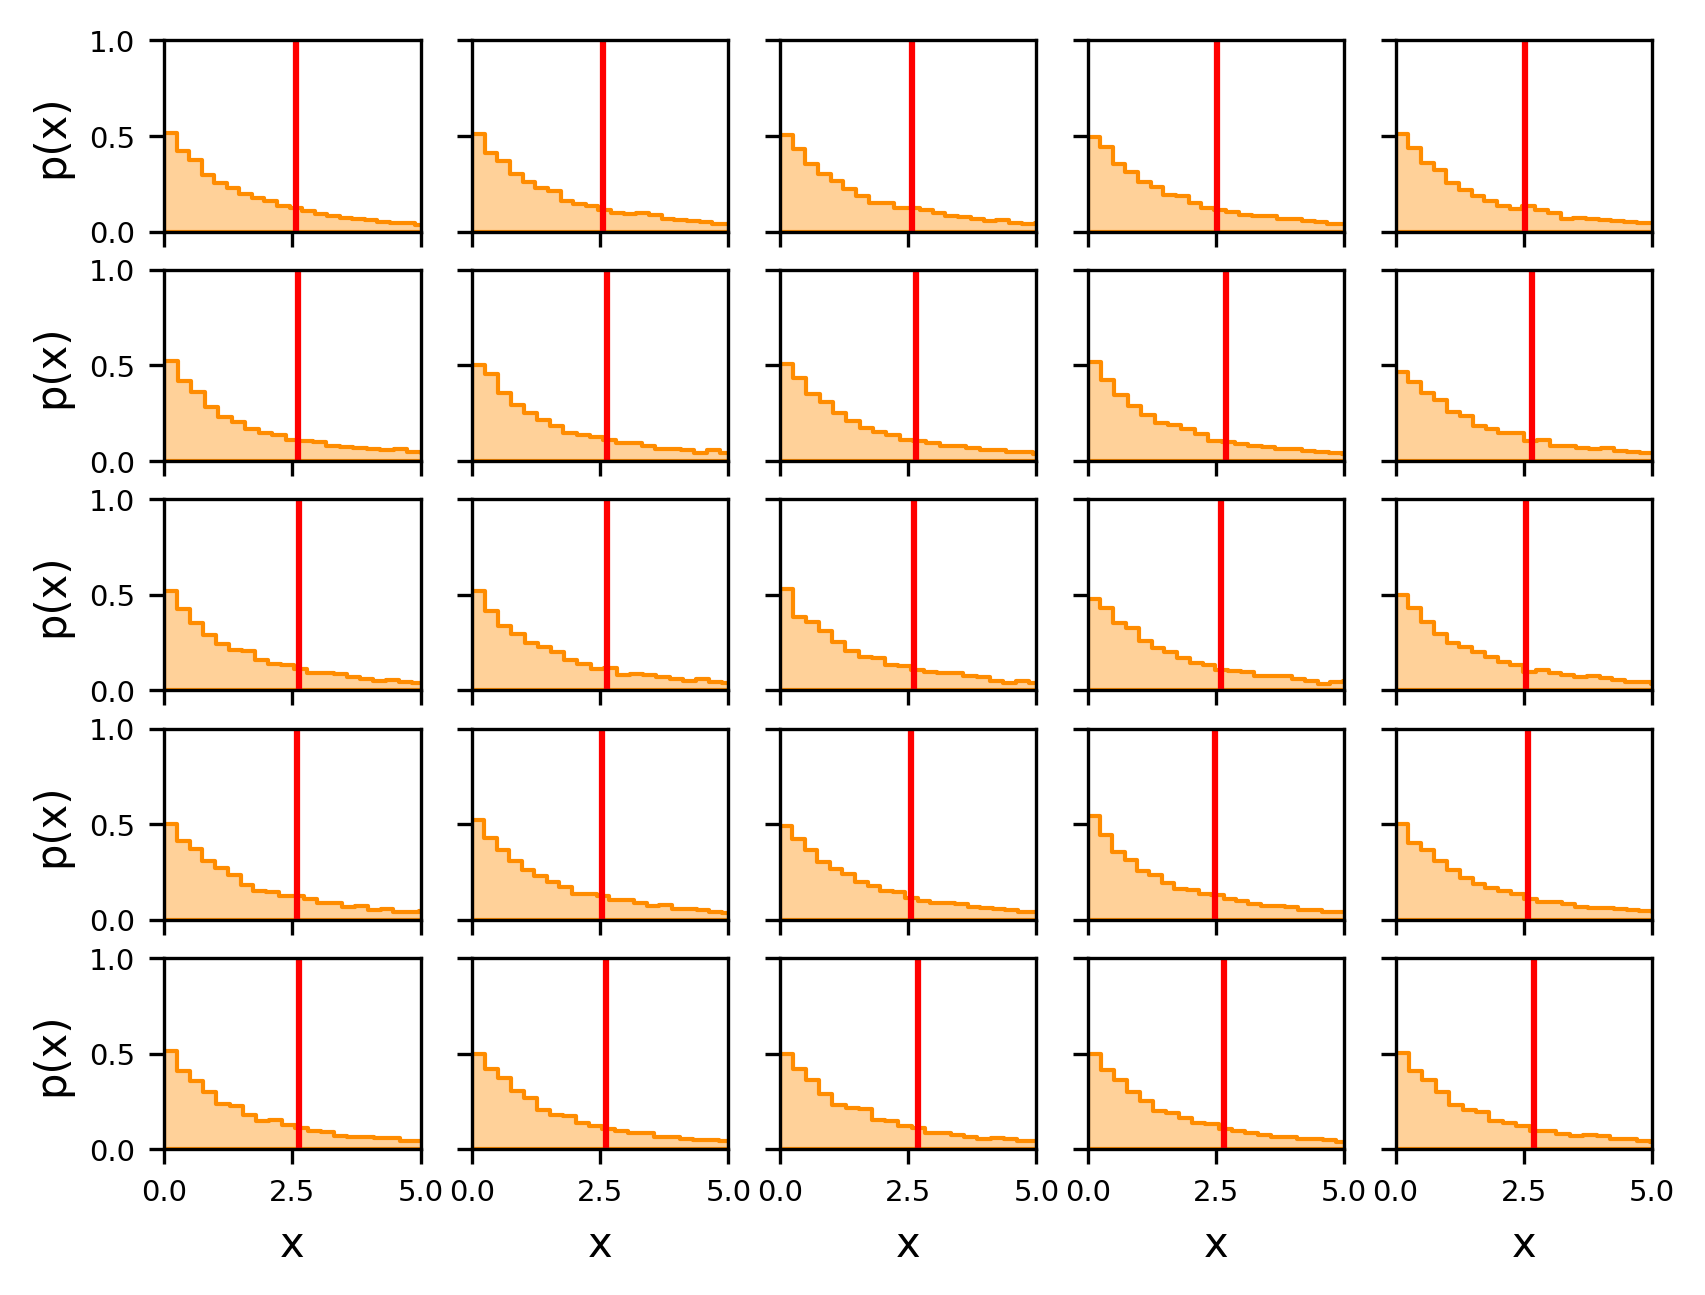

In [32]:
fig, axs = plt.subplots(5, 5, dpi=300, sharex=True, sharey=True)
for idx, ax in enumerate(axs.ravel()):
    sns.histplot(
        x_samples[:, idx],
        ax=ax,
        stat="density",
        element="step",
        # kde=True,
        color="darkorange",
        # label="No task",
        alpha=0.4,
    )
    avg_samples = x_samples[:, idx].mean()
    
    ax.axvline(avg_samples, color="red")
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1)
    ax.set_xlabel("x")
    ax.set_ylabel("p(x)")
    ax.tick_params(axis="both", which="both", labelsize=7)


In [33]:
x_samples.shape

torch.Size([10000, 25])

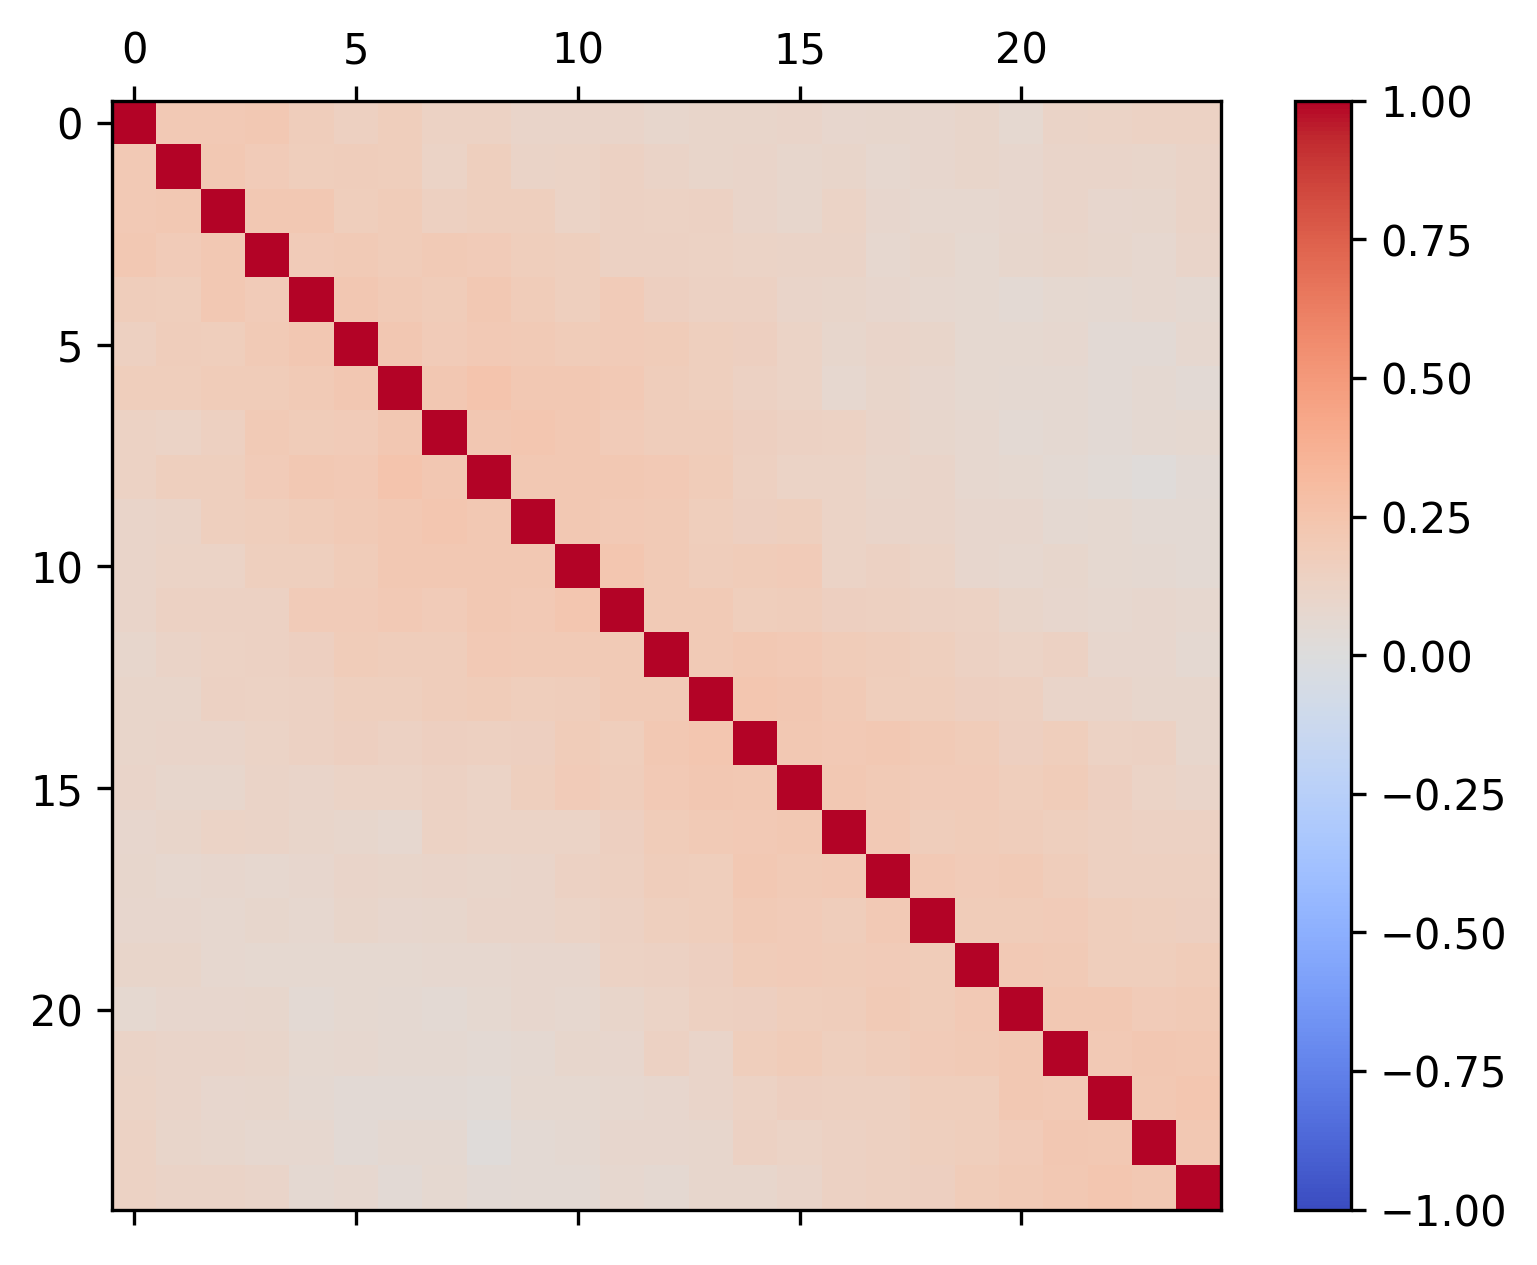

In [34]:
corr = torch.corrcoef(x_samples.T)
# plot the correlation matrix
fig, ax = plt.subplots(dpi=300)
cax = ax.matshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax)

Text(0, 0.5, 'Frequency')

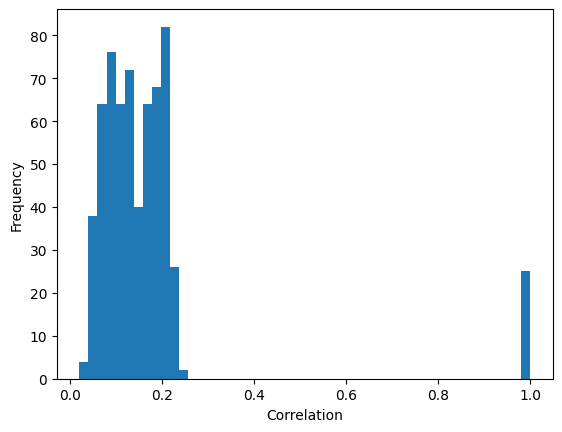

In [35]:
# plot a histogram of correlations
fig, ax = plt.subplots(dpi=100)
ax.hist(corr.flatten(), bins=50)
ax.set_xlabel("Correlation")
ax.set_ylabel("Frequency")


In [36]:
x_samples.shape

torch.Size([10000, 25])

In [37]:
x_pfs = torch.Tensor(generate_gabors(orientations=x_preferred.flatten().tolist()))

In [38]:
x_pfs.shape

torch.Size([25, 12, 12])

In [39]:
x_samples.shape

torch.Size([10000, 25])

In [40]:
x_samples @ x_pfs.reshape(x_pfs.shape[0], -1)

tensor([[ 2.9718e-02, -6.2821e-02, -3.2330e-01,  ..., -8.6196e-01,
          3.0154e-01,  2.8467e-01],
        [ 1.4232e-03,  6.8891e-02,  2.1784e-01,  ..., -5.9886e-01,
         -7.5006e-01,  3.0495e-01],
        [ 8.9485e-03, -1.0109e-01, -2.0274e-02,  ..., -1.0446e+00,
         -2.0845e-01,  3.5535e-01],
        ...,
        [ 1.6265e-01,  1.4736e-01, -5.7461e-01,  ..., -1.0283e+00,
          8.8643e-01,  9.6103e-01],
        [ 2.1185e-02,  6.8942e-03, -8.7860e-02,  ..., -2.2864e+00,
         -6.7163e-01,  2.0818e-01],
        [ 4.0074e-02,  1.5715e-01,  3.9140e-02,  ..., -2.4718e+00,
         -2.8230e-01,  5.0749e-01]])

In [41]:
(x_samples @ x_pfs.reshape(x_pfs.shape[0], -1)).shape

torch.Size([10000, 144])